# Seizure Detection — End-to-End ML Pipeline

This notebook implements a complete seizure detection experiment on the **SWEZ iEEG short** dataset
(`data/remote/swiss_eeg_short/`).

The dataset consists of intracranial EEG (iEEG) recordings from epilepsy patients, each `.mat` file
containing a single seizure event captured at 256 Hz across up to 20 channels. Because no sample-level
onset/offset annotations are available, seizure labels are derived from a fixed-margin rule: the
first and last 3 minutes of each file are treated as non-seizure background, and everything in
between is assumed to be ictal activity.

The goal is to compare four detection strategies — raw vs HMM-smoothed output, on both a binary
(seizure/non-seizure) and a finer 4-class (non/pre/ictal/post) formulation — evaluated with
Leave-One-Subject-Out cross-validation to simulate how well a model generalises to an unseen patient.

| Step | Detail |
|------|--------|
| Signal | 15 CobraBox features per 2 s window (0.5 s step) |
| Labels | Binary (seizure / non-seizure) **and** 4-class (non- / pre- / seizure / post-) from fixed-margin rule |
| Feature selection | RFE sweep (k = 3 / 5 / 8 / 10 / all), scored on 4-class balanced accuracy |
| Validation | Leave-One-Subject-Out (LOSO) |
| Models | Logistic Regression, Random Forest |
| Post-processing | Viterbi HMM per seizure file |
| Comparison | 2 × 2 grid: Binary vs 4-class × Raw vs HMM |

## Labeling assumption

The `.mat` files have no onset/offset annotations. Fixed-margin rule:

- first `NON_SEIZURE_MARGIN_SECONDS` (3 min) → non-seizure
- last  `NON_SEIZURE_MARGIN_SECONDS` (3 min) → non-seizure
- 30 s on each side of the seizure boundary → pre- / post-seizure (4-class only)
- everything in between → seizure

## Dependencies

The pipeline uses three groups of libraries:

- **Signal processing / data:** `numpy`, `scipy.io` (MAT file loading), `xarray` (labelled arrays
  that CobraBox features expect), `pandas` (tabular results).
- **Machine learning:** `scikit-learn` — `StandardScaler` (per-fold z-score normalisation),
  `LogisticRegression` and `RandomForestClassifier` (classifiers), `RFE` (feature selection),
  `LeaveOneGroupOut` (LOSO split), and standard metrics.
- **CobraBox:** `cobrabox` (`cb`) provides the domain-specific EEG features via its `feature.*`
  API. Each feature accepts a `SignalData` object and returns a labelled result array.

`warnings.filterwarnings` suppresses sklearn deprecation noise that would clutter the output
without affecting results.

In [50]:
import warnings
from itertools import pairwise
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import xarray as xr
from matplotlib.patches import Patch
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, recall_score, roc_auc_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

import cobrabox as cb

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")

## 1. Configuration

All tunable parameters are centralised here so the entire experiment can be reproduced or varied
by changing a single cell.

**Key choices and their rationale:**

- **Window 2 s / step 0.5 s** — 2 s captures the temporal dynamics of typical ictal rhythms while
  remaining short enough to localise onset. A 75 % overlap (0.5 s step) gives smooth probability
  traces and enough temporal resolution for the HMM.
- **3-min non-seizure margin** — The SWEZ short recordings always start and end in interictal
  background. 3 minutes provides a generous non-seizure buffer that avoids mislabelling
  the peri-ictal transition as background.
- **`QUICK_TEST`** — Limits the run to three subjects so you can verify the full pipeline quickly
  before committing to the full 15-subject, ~30-min extraction run.
- **`REEXTRACT`** — Feature extraction is the expensive step. CSVs are cached by default;
  set this flag to `True` only when features or window parameters change.
- **`N_SUBJECTS_PLOT`** — Keeps the visualisation section from generating dozens of figures;
  set to `None` to plot every fold.

**What runs next:** Section 2 discovers which files exist on disk and builds the subject-to-file map.

In [51]:
# Paths
DATA_DIR = Path("../data/remote/swiss_eeg_short")
OUT_DIR = Path("./derived_features_swec_short")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Signal
FS = 256.0
# Sliding window
WINDOW_SECONDS = 2.0
STEP_SECONDS = 0.5
WINDOW_SIZE = int(WINDOW_SECONDS * FS)
STEP_SIZE = int(STEP_SECONDS * FS)

# Labeling
NON_SEIZURE_MARGIN_SECONDS = 3 * 60  # 180 s — first/last 3 min -> non-seizure
PRE_POST_WINDOW_SECONDS = 30  # transition zone width on each side

# Class index for "seizure" in
# CLASS_ORDER = ["non_seizure", "pre_seizure", "seizure", "post_seizure"]
SEIZURE_CLASS = 2

# Feature selection: k values to sweep; all-features baseline appended automatically
K_STEPS = [3, 5, 8, 10]
MIN_K = 5  # 1-SE rule floor — never select fewer features than this


# ── XGBoost wrapper ───────────────────────────────────────────────────────────
# XGBClassifier has no class_weight="balanced". This subclass injects balanced
# sample weights automatically so the same .fit(X, y) interface works for both
# binary and 4-class targets without changing any downstream code.
class BalancedXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        kwargs.setdefault("sample_weight", compute_sample_weight("balanced", y))
        return super().fit(X, y, **kwargs)


# Classifiers
CLASSIFIERS = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000, class_weight="balanced", solver="lbfgs"
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=10, random_state=42, n_jobs=-1
    ),
    "XGBoost": BalancedXGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    ),
}

# Parallelism: number of workers for feature extraction (-1 = all CPU cores)
N_JOBS = -1

# Quick-test mode: set True to run on 3 subjects only
QUICK_TEST = False
QUICK_TEST_SUBJECTS = ["ID1", "ID2", "ID5"]

# Feature extraction: set True to delete existing CSVs and re-extract from scratch
REEXTRACT = False

# Visualisation
N_SUBJECTS_PLOT = 4  # subjects to show in time-series plots; None = all
VIS_CLF = "LogisticRegression"

print(f"Window: {WINDOW_SECONDS}s  |  Step: {STEP_SECONDS}s")
print(
    f"Non-seizure margin: {NON_SEIZURE_MARGIN_SECONDS / 60:.0f} min  |  "
    f"Pre/post zone: {PRE_POST_WINDOW_SECONDS}s"
)
print(f"Channels: all available  |  Output: {OUT_DIR}")
print(f"Re-extract: {REEXTRACT}  |  Workers: {N_JOBS}")
print(f"Classifiers: {list(CLASSIFIERS)}")
print(f"Feature selection: k in {[*K_STEPS, 15]}, min k = {MIN_K}")

Window: 2.0s  |  Step: 0.5s
Non-seizure margin: 3 min  |  Pre/post zone: 30s
Channels: all available  |  Output: derived_features_swec_short
Re-extract: False  |  Workers: -1
Classifiers: ['LogisticRegression', 'RandomForest', 'XGBoost']
Feature selection: k in [3, 5, 8, 10, 15], min k = 5


## 2. Discover seizure files

Before extracting features we need a complete inventory of recordings and their subject ownership.

**Why subject merging matters for LOSO:** The dataset contains split sessions for two patients:
`ID13a`/`ID13b` and `ID14a`/`ID14b`. If these were treated as separate subjects, the LOSO loop would
train on one half and test on the other — effectively leaking information about that patient into
the training set. Mapping both suffixes to the same canonical ID (`ID13`, `ID14`) ensures they are
held out together, giving a fair estimate of out-of-subject generalisation.

**What runs next:** Section 3 defines the feature extraction functions that will be applied to
every window of every file discovered here.

In [37]:
def canonical_subject_id(folder_name: str) -> str:
    return folder_name.rstrip("ab")


all_files = []
for subj_dir in sorted(DATA_DIR.iterdir()):
    if not subj_dir.is_dir():
        continue
    folder = subj_dir.name
    subject_id = canonical_subject_id(folder)
    for p in sorted(subj_dir.glob("Sz*.mat")):
        all_files.append({"path": p, "folder": folder, "subject_id": subject_id})

if QUICK_TEST:
    all_files = [f for f in all_files if f["folder"] in QUICK_TEST_SUBJECTS]

print(f"Total seizure files: {len(all_files)}")
summary = pd.DataFrame(all_files).groupby("subject_id")["path"].count().rename("seizure_files")
print(summary.to_string())

Total seizure files: 98
subject_id
ID1     13
ID10     5
ID11     2
ID12    10
ID13     7
ID14     7
ID15     3
ID16     6
ID2      4
ID4     14
ID5     10
ID6      4
ID7      2
ID8      2
ID9      9


## 3. Feature extraction helpers

This section defines the **15 scalar features** computed per 2-second window. All features are
implemented as CobraBox feature objects and applied via `.apply(signal)`. Two input strategies are
used depending on what the feature measures:

- **Mean-channel signal** — the spatial mean across all channels is taken first, collapsing the
  recording to a single 512-sample trace. Used for features that describe the dominant
  signal (LineLength, AmplitudeVariation, SampleEntropy, Bandpower).
- **Full multi-channel signal** — all available channels are passed as a matrix. Used for connectivity
  features that measure pairwise relationships (Correlation, Coherence) and for SpikeCount which
  detects outliers across the entire signal.

---

### 1 — LineLength (`linelength`)

**Formula:**

$$\mathrm{LL} = \sum_{t=1}^{T} \bigl|x[t] - x[t-1]\bigr|$$

Sum of absolute sample-to-sample differences — the total path length of the signal waveform.

| | |
|---|---|
| **Input** | Mean-channel signal (1 × T) |
| **Output** | 1 scalar |
| **Range** | [0, ∞), same units as the EEG |
| **Parameters** | None |

**Seizure relevance:** Ictal EEG has rapid, high-amplitude oscillations that dramatically increase
path length. LineLength is one of the oldest and most reliable seizure detectors — it rises sharply
within seconds of onset and remains elevated throughout the seizure.

---

### 2 — AmplitudeVariation (`ampvar`)

**Formula:**

$$\mathrm{AV} = \mathrm{std}(x) = \sqrt{\frac{1}{T}\sum_{t=1}^{T}(x[t] - \bar{x})^2}$$

Standard deviation of the signal within the window.

| | |
|---|---|
| **Input** | Mean-channel signal (1 × T) |
| **Output** | 1 scalar |
| **Range** | [0, ∞), same units as the EEG |
| **Parameters** | None |

**Seizure relevance:** Captures amplitude envelope dynamics. Seizures produce bursts of
high-amplitude activity; interictal background has lower, more stable amplitude. Complementary to
LineLength — AV responds to amplitude swings while LL responds to frequency content.

---

### 3 — SampleEntropy (`sampen`)

**Formula:**

$$\mathrm{SampEn}(m, r) = -\log_2 \frac{\Phi(m+1)}{\Phi(m)}$$

where $\Phi(m)$ counts template matches of length $m$ within Chebyshev tolerance $r$.
CobraBox defaults: $m = 2$, $r = 0.2 \cdot \mathrm{std}(x)$. The inner matching loop
is JIT-compiled with Numba and parallelised with `prange`.

| | |
|---|---|
| **Input** | Mean-channel signal (1 × T) |
| **Output** | 1 scalar; NaN if no template matches at tolerance r |
| **Range** | [0, ∞) bits; **lower = more regular** |
| **Parameters** | `m=2`, `r=None` → 0.2·std, `log_base=2` |

**Seizure relevance:** Seizures produce stereotyped rhythmic patterns (e.g. 3 Hz spike-wave)
that are highly regular — SampleEntropy **drops**. Interictal background is more complex and
random — SampleEntropy is **higher**. Note the direction is *opposite* to the other features;
after per-file normalisation the model sees a negative deviation during the seizure core.

---

### 4 — SpikeCount (`spike_count`)

**Formula:**

$$Q_1,\, Q_3 = \text{25th, 75th percentile across all samples (all channels)}$$
$$\mathrm{IQR} = Q_3 - Q_1$$
$$\mathrm{SpikeCount} = \#\bigl\{x[i] \notin [Q_1 - 1.5 \cdot \mathrm{IQR},\; Q_3 + 1.5 \cdot \mathrm{IQR}]\bigr\}$$

Counts IQR-outlier samples across the entire **flattened** signal (all channels × all time points
in the window). The 1.5×IQR multiplier is the standard Tukey fence.

| | |
|---|---|
| **Input** | Full multi-channel signal (n_ch × T), flattened to 1-D |
| **Output** | 1 scalar (integer count, returned as float) |
| **Range** | [0, n_ch × T] |
| **Parameters** | None (IQR multiplier fixed at 1.5) |

**Seizure relevance:** Epileptiform spikes are hallmarks of ictal and interictal activity. The
IQR fence adapts to each window's own amplitude distribution, making the detector robust to
amplitude variability across subjects and sessions.

---

### 5 — Correlation (`corr_mean`, `corr_max`, `corr_std`)

**Formula:**

$$r(X_i, X_j) = \frac{\mathrm{cov}(X_i, X_j)}{\sigma_{X_i}\, \sigma_{X_j}} \quad \in [-1,\, 1]$$

Pearson correlation computed for every channel pair via `np.corrcoef`, yielding a symmetric
$n \times n$ matrix ($n$ = channel count). The **upper triangle** (n*(n-1)/2 unique pairs) is aggregated:

$$\mathrm{corr\_mean} = \mathrm{mean}(r_{ij}), \quad
  \mathrm{corr\_max}  = \max(r_{ij}), \quad
  \mathrm{corr\_std}  = \mathrm{std}(r_{ij}) \quad i < j$$

| | |
|---|---|
| **Input** | Full multi-channel signal (n_ch × T) |
| **Output** | n×n matrix → 3 scalars |
| **Range** | mean, max ∈ [−1, 1]; std ∈ [0, 1] |
| **Parameters** | `method="pearson"`, `dim="time"` |

**Seizure relevance:** Seizures spread across brain regions and synchronise electrode activity.
High inter-channel correlation indicates ictal propagation. `corr_max` captures the peak pairwise
synchrony; `corr_std` captures how evenly synchrony spreads (focal vs. generalised onset).

---

### 6 — Coherence (`coherence_mean`, `coherence_max`, `coherence_std`)

**Formula:**

$$C_{xy}(f) = \frac{|P_{xy}(f)|^2}{P_{xx}(f)\, P_{yy}(f)} \quad \in [0,\, 1]$$

Magnitude-squared coherence estimated via **Welch's method** (Hann window, 50 % overlap,
`nperseg = min(256, T)`). The frequency-averaged scalar per channel pair:

$$\bar{C}_{xy} = \frac{1}{N_f}\sum_f C_{xy}(f)$$

The $n \times n$ result is aggregated over the upper triangle identically to Correlation.

| | |
|---|---|
| **Input** | Full multi-channel signal (n_ch × T) |
| **Output** | n×n matrix → 3 scalars |
| **Range** | mean, max ∈ [0, 1]; std ∈ [0, 0.5] |
| **Parameters** | `nperseg = min(256, T)` |

**Seizure relevance:** Coherence measures **frequency-domain synchrony** — two channels can be
coherent even when not amplitude-locked (which Correlation would miss). Ictal oscillations are
driven by synchronous thalamo-cortical rhythms that are visible in the coherence spectrum,
particularly in the 1–30 Hz range where most seizure patterns occur.

---

### 7 — Bandpower (`bandpower_delta` … `bandpower_gamma`)

**Formula:**

$$P_\text{band} = \int_{f_\text{low}}^{f_\text{high}} \mathrm{PSD}(f)\, df
  \approx \sum_f \mathrm{PSD}(f) \cdot \Delta f \quad (\text{trapezoidal rule})$$

PSD is estimated with `scipy.signal.welch` (Hann window, `nperseg = min(256, T)`).
Integration uses `np.trapezoid` over the bins that fall within the band boundaries.

| Band | Range | Typical ictal role |
|------|-------|--------------------|
| **delta** | 1–4 Hz | Slow ictal discharges; post-ictal suppression |
| **theta** | 4–8 Hz | Rhythmic ictal onset in temporal lobe seizures |
| **alpha** | 8–12 Hz | Often suppressed in focal seizures |
| **beta** | 12–30 Hz | Elevated at many seizure onsets (fast activity) |
| **gamma** | 30–45 Hz | High-frequency oscillations — hallmark of ictal high-activity |

| | |
|---|---|
| **Input** | Mean-channel signal (1 × T) |
| **Output** | 5 scalars (one per band) |
| **Range** | [0, ∞) signal²/Hz |
| **Parameters** | `bands=None` → default 5 bands; `nperseg = min(256, T)` |

**Seizure relevance:** Seizures produce a characteristic spectral redistribution: gamma and beta
rise sharply at onset, alpha may transiently decrease, delta can increase in post-ictal
suppression. All five bands together capture this spectral fingerprint.

---

### Aggregation summary

| CobraBox feature | Raw output shape | Notebook extraction | Final column(s) |
|-----------------|------------------|---------------------|-----------------|
| `LineLength` | `(1,)` | `_scalar(result)` | `linelength` |
| `AmplitudeVariation` | `(1,)` | `_scalar(result)` | `ampvar` |
| `SampleEntropy` | `(1,)` | `_scalar(result)` | `sampen` |
| `SpikeCount` | `()` scalar | `_scalar(result)` | `spike_count` |
| `Correlation` | `(n, n)` | upper-triangle mean / max / std | `corr_mean`, `corr_max`, `corr_std` |
| `Coherence` | `(n, n)` | upper-triangle mean / max / std | `coherence_mean`, `coherence_max`, `coherence_std` |
| `Bandpower` | `(5, 1)` | band-coordinate loop | `bandpower_{delta,theta,alpha,beta,gamma}` |

**What runs next:** Section 4 applies these helpers to every sliding window of every file and
caches the result to CSV.


In [27]:
_FEAT_LINELENGTH = cb.feature.LineLength()
_FEAT_AMPVAR = cb.feature.AmplitudeVariation()
_FEAT_SAMPEN = cb.feature.SampleEntropy()
_FEAT_SPIKECOUNT = cb.feature.SpikeCount()
_FEAT_CORRELATION = cb.feature.Correlation()
_FEAT_COHERENCE = cb.feature.Coherence()
_FEAT_BANDPOWER = cb.feature.Bandpower()

FEATURE_NAMES = [
    "linelength",
    "ampvar",
    "sampen",
    "spike_count",
    "corr_mean",
    "corr_max",
    "corr_std",
    "coherence_mean",
    "coherence_max",
    "coherence_std",
    "bandpower_delta",
    "bandpower_theta",
    "bandpower_alpha",
    "bandpower_beta",
    "bandpower_gamma",
]
print(f"Features per window: {len(FEATURE_NAMES)}")


def _mean_channel_signal(win: cb.SignalData) -> cb.SignalData:
    mean_vals = win.data.mean(dim="space").to_numpy()
    da = xr.DataArray(
        mean_vals[np.newaxis, :],
        dims=("space", "time"),
        coords={"space": ["mean"], "time": win.data.coords["time"].to_numpy()},
    )
    return cb.SignalData.from_xarray(da, sampling_rate=win.sampling_rate)


def _scalar(result) -> float:
    return float(np.asarray(result.data).ravel()[0])


def _agg_upper_tri(name: str, arr: np.ndarray) -> dict:
    arr = np.asarray(arr).squeeze()
    m = arr.shape[0]
    mask = np.triu(np.ones((m, m), dtype=bool), k=1)
    vals = arr[mask]
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return {f"{name}_mean": 0.0, f"{name}_max": 0.0, f"{name}_std": 0.0}
    return {
        f"{name}_mean": float(vals.mean()),
        f"{name}_max": float(vals.max()),
        f"{name}_std": float(vals.std()),
    }


def make_window_signal(signal: cb.SignalData, start: int, end: int) -> cb.SignalData:
    win_da = signal.data.isel(time=slice(start, end)).copy()
    win_da.attrs = dict(signal.data.attrs)
    return cb.SignalData.from_xarray(win_da, sampling_rate=signal.sampling_rate)


def extract_window_features(win: cb.SignalData) -> dict:
    mean_sig = _mean_channel_signal(win)
    row: dict = {
        "linelength": _scalar(_FEAT_LINELENGTH.apply(mean_sig)),
        "ampvar": _scalar(_FEAT_AMPVAR.apply(mean_sig)),
        "sampen": _scalar(_FEAT_SAMPEN.apply(mean_sig)),
        "spike_count": _scalar(_FEAT_SPIKECOUNT.apply(win)),
    }
    row.update(_agg_upper_tri("corr", np.asarray(_FEAT_CORRELATION.apply(win).data)))
    row.update(_agg_upper_tri("coherence", np.asarray(_FEAT_COHERENCE.apply(win).data)))
    bp_res = _FEAT_BANDPOWER.apply(mean_sig)
    bp_arr = np.asarray(bp_res.data).ravel()
    for i, band in enumerate(bp_res.data.coords["band_index"].values):
        row[f"bandpower_{band}"] = float(bp_arr[i])
    return row


def label_window(
    start_s: float, end_s: float, sample_is_seizure: np.ndarray, fs: float
) -> tuple[str, float]:
    s = max(0, min(round(start_s * fs), len(sample_is_seizure)))
    e = max(0, min(round(end_s * fs), len(sample_is_seizure)))
    sl = sample_is_seizure[s:e]
    if sl.size == 0:
        return "non_seizure", 0.0
    frac = float(sl.mean())
    return ("seizure" if frac > 0.5 else "non_seizure"), frac

Features per window: 15


## 4. Extract features for every seizure file

This is the most compute-intensive step. Each `.mat` file is loaded, sliced into overlapping
windows, and all scalar features are computed per window. Results are written to a per-file CSV
under `OUT_DIR`.

---

### Window construction

Each file is split into overlapping 2-second windows with a 0.5-second step (75 % overlap):

```
window size : WINDOW_SIZE = int(2.0 * 256) = 512 samples
step size   : STEP_SIZE   = int(0.5 * 256) = 128 samples
total wins  : (n_samples - 512) // 128 + 1  per file
```

**Channel handling.** All channels present in the `.mat` file are used — there is no cap and no
zero-padding. The actual channel count varies across subjects and recordings (e.g. 20, 32, 64
channels). The count is stored in the `n_channels` column of the feature CSV and is later used
as a feature in the classifier (higher channel count correlates with more advanced electrode
configurations used in specific clinical protocols).

| Scenario | What the code does |
|----------|--------------------|
| Any `n_ch_avail` | Reads all `n_ch_avail` channels — `space_coords = [f"ch{i:02d}" for i in range(n_ch_avail)]` |
| Variable channel count across files | Each file produces its own `SignalData` with the correct number of spatial dimensions |
| `n_channels` feature | Saved per-window in the CSV; **not** z-scored (constant within a file, informative across subjects) |

Two signal views are then derived per window:

| View | How | Used for |
|------|-----|----------|
| **Mean-channel** | `eeg[window].mean(axis="space")` — spatial average across all channels into a single 512-sample trace | Univariate features (LL, AV, SampEn, Bandpower) |
| **Full multi-channel** | All `n_ch_avail` x 512 samples as a matrix | Connectivity features (Correlation, Coherence) and SpikeCount |

---

### Computed features

#### Time-domain — univariate (applied to mean-channel signal)

| Column | CobraBox call | Computation |
|--------|---------------|-------------|
| `linelength` | `feat_ll.apply(mean_sig)` | $\sum_t \|x[t]-x[t-1]\|$ — total path length of the waveform |
| `ampvar` | `feat_av.apply(mean_sig)` | $\mathrm{std}(x)$ — standard deviation within the window |
| `sampen` | `feat_se.apply(mean_sig)` | $-\log_2(\Phi(m{+}1)/\Phi(m))$, $m=2$, $r=0.2\cdot\mathrm{std}(x)$ — regularity measure; **lower = more regular** |

#### Time-domain — multivariate (applied to full multi-channel signal)

| Column | CobraBox call | Computation |
|--------|---------------|-------------|
| `spike_count` | `feat_sc.apply(win)` | IQR outlier count across all flattened samples: $\#\{x \notin [Q_1-1.5\cdot\mathrm{IQR},\; Q_3+1.5\cdot\mathrm{IQR}]\}$ |

#### Connectivity — Correlation (applied to full multi-channel signal)

Pearson correlation matrix $r_{ij}$ for all unique channel pairs; upper triangle aggregated
into three scalars via `_agg_upper_tri("corr", ...)`:

| Column | Value |
|--------|-------|
| `corr_mean` | Mean of all pairwise Pearson $r$ values |
| `corr_max` | Maximum pairwise $r$ — peak synchrony in the window |
| `corr_std` | Std of pairwise $r$ — spread of synchrony (focal vs. generalised) |

#### Connectivity — Coherence (applied to full multi-channel signal)

Magnitude-squared coherence $C_{xy}(f) = |P_{xy}|^2/(P_{xx}P_{yy})$ estimated with Welch's
method (Hann window, 50 % overlap, `nperseg = min(256, T)`), then frequency-averaged per pair;
upper triangle aggregated identically via `_agg_upper_tri("coherence", ...)`:

| Column | Value |
|--------|-------|
| `coherence_mean` | Mean frequency-averaged coherence across all pairs |
| `coherence_max` | Peak coherence — strongest frequency-domain coupling |
| `coherence_std` | Spread of coherence values |

#### Frequency-domain — Bandpower (applied to mean-channel signal)

Welch PSD integrated over each band with the trapezoidal rule. Band boundaries:

| Column | Band | Frequency range |
|--------|------|-----------------|
| `bandpower_delta` | delta | 1–4 Hz |
| `bandpower_theta` | theta | 4–8 Hz |
| `bandpower_alpha` | alpha | 8–12 Hz |
| `bandpower_beta` | beta | 12–30 Hz |
| `bandpower_gamma` | gamma | 30–45 Hz |

#### Meta — channel count

| Column | Value |
|--------|-------|
| `n_channels` | Number of EEG channels in this recording. Constant within a file; varies across subjects. Used as-is (no per-file z-score). |

---

### Window labeling

The binary label is derived sample-by-sample from a fixed-margin mask:

```
is_seizure[t < 180 s]              = 0  (non-seizure)
is_seizure[t > total_s - 180 s]   = 0  (non-seizure)
is_seizure[everything else]        = 1  (seizure)
```

A window is labelled `seizure` if **more than 50 %** of its samples fall in the ictal zone.
The 4-class label (adding pre-/post-seizure transition zones) is computed in Section 5 after
all CSVs are loaded, because it requires knowing the total recording duration per file.

---

### Engineering choices

**Why cache to CSV?** Extraction across 98 files takes 20–30 min on a single core. Caching lets
subsequent runs — changing classifiers, labels, or RFE parameters — reuse existing features
without re-running. Set `REEXTRACT = True` only when feature code or window parameters change.

**Why parallelise at the file level?** Each file reads its own `.mat`, writes its own CSV, and
shares no mutable state — an embarrassingly parallel workload. `joblib.Parallel(backend="loky")`
spawns worker processes that bypass Python's GIL. `N_JOBS = -1` uses all physical cores.

**Why is `extract_one_file` self-contained?** Multiprocessing requires all objects passed to
workers to be picklable. Rather than relying on module-level feature instances being picklable,
each worker instantiates its own fresh feature objects. The overhead (98 instantiations) is
negligible compared to the actual computation.

**What runs next:** Section 5 loads all cached CSVs, applies per-file z-score normalisation to
remove inter-subject amplitude differences, and constructs the binary and 4-class label vectors.


In [28]:
from joblib import Parallel, delayed

if REEXTRACT:
    stale = list(OUT_DIR.glob("*_features.csv"))
    for p in stale:
        p.unlink()
    print(f"Deleted {len(stale)} stale CSV(s).")
else:
    existing = len(list(OUT_DIR.glob("*_features.csv")))
    print(f"REEXTRACT=False — reusing {existing} existing CSV(s).")


def extract_one_file(file_info: dict) -> tuple:
    import numpy as np
    import pandas as pd
    import xarray as xr

    import cobrabox as cb

    feat_ll = cb.feature.LineLength()
    feat_av = cb.feature.AmplitudeVariation()
    feat_se = cb.feature.SampleEntropy()
    feat_sc = cb.feature.SpikeCount()
    feat_cor = cb.feature.Correlation()
    feat_coh = cb.feature.Coherence()
    feat_bp = cb.feature.Bandpower()

    path = file_info["path"]
    subject_id = file_info["subject_id"]
    folder = file_info["folder"]
    file_stem = f"{folder}_{path.stem}"
    label = f"{folder}/{path.name}"

    out_path = OUT_DIR / f"{file_stem}_features.csv"
    if out_path.exists():
        return label, out_path

    mat = scipy.io.loadmat(str(path))
    eeg_raw = np.asarray(mat["EEG"], dtype=float)
    n_samples, n_ch_avail = eeg_raw.shape

    # Use all available channels — no cap, no zero-padding.
    space_coords = [f"ch{i:02d}" for i in range(n_ch_avail)]
    da = xr.DataArray(
        eeg_raw.T,
        dims=("space", "time"),
        coords={"space": space_coords, "time": np.arange(n_samples) / FS},
    )
    signal = cb.SignalData.from_xarray(da, sampling_rate=FS)

    t = np.arange(n_samples) / FS
    total_s = n_samples / FS
    is_seizure = np.ones(n_samples, dtype=int)
    is_seizure[t < NON_SEIZURE_MARGIN_SECONDS] = 0
    is_seizure[t > (total_s - NON_SEIZURE_MARGIN_SECONDS)] = 0

    rows = []
    for w_idx, s in enumerate(range(0, n_samples - WINDOW_SIZE + 1, STEP_SIZE)):
        e = s + WINDOW_SIZE
        win = make_window_signal(signal, s, e)
        start_s = s / FS
        end_s = e / FS
        target, frac = label_window(start_s, end_s, is_seizure, FS)

        mean_sig = _mean_channel_signal(win)
        row = {
            "subject_id": subject_id,
            "file_stem": file_stem,
            "n_channels": n_ch_avail,
            "window_idx": w_idx,
            "window_start_s": start_s,
            "window_end_s": end_s,
            "window_mid_s": (start_s + end_s) / 2,
            "seizure_fraction": frac,
            "target": target,
            "linelength": _scalar(feat_ll.apply(mean_sig)),
            "ampvar": _scalar(feat_av.apply(mean_sig)),
            "sampen": _scalar(feat_se.apply(mean_sig)),
            "spike_count": _scalar(feat_sc.apply(win)),
        }
        row.update(_agg_upper_tri("corr", np.asarray(feat_cor.apply(win).data)))
        row.update(_agg_upper_tri("coherence", np.asarray(feat_coh.apply(win).data)))
        bp_res = feat_bp.apply(mean_sig)
        bp_arr = np.asarray(bp_res.data).ravel()
        for i, band in enumerate(bp_res.data.coords["band_index"].values):
            row[f"bandpower_{band}"] = float(bp_arr[i])
        rows.append(row)

    pd.DataFrame(rows).to_csv(out_path, index=False)
    return label, out_path


n_total = len(all_files)
print(f"Extracting features for {n_total} files (n_jobs={N_JOBS}) ...")
results = Parallel(n_jobs=N_JOBS, backend="loky")(delayed(extract_one_file)(fi) for fi in all_files)
for i, (label, out) in enumerate(results, 1):
    print(f"  [{i:3d}/{n_total}] {label:30s}  ->  {out.name if out else 'error'}")
print("\nExtraction complete.")

Deleted 98 stale CSV(s).
Extracting features for 98 files (n_jobs=-1) ...
  [  1/98] ID1/Sz1.mat                     ->  ID1_Sz1_features.csv
  [  2/98] ID1/Sz10.mat                    ->  ID1_Sz10_features.csv
  [  3/98] ID1/Sz11.mat                    ->  ID1_Sz11_features.csv
  [  4/98] ID1/Sz12.mat                    ->  ID1_Sz12_features.csv
  [  5/98] ID1/Sz13.mat                    ->  ID1_Sz13_features.csv
  [  6/98] ID1/Sz2.mat                     ->  ID1_Sz2_features.csv
  [  7/98] ID1/Sz3.mat                     ->  ID1_Sz3_features.csv
  [  8/98] ID1/Sz4.mat                     ->  ID1_Sz4_features.csv
  [  9/98] ID1/Sz5.mat                     ->  ID1_Sz5_features.csv
  [ 10/98] ID1/Sz6.mat                     ->  ID1_Sz6_features.csv
  [ 11/98] ID1/Sz7.mat                     ->  ID1_Sz7_features.csv
  [ 12/98] ID1/Sz8.mat                     ->  ID1_Sz8_features.csv
  [ 13/98] ID1/Sz9.mat                     ->  ID1_Sz9_features.csv
  [ 14/98] ID10/Sz1.mat               

## 5. Load features & build labels

All per-file CSVs are concatenated into a single design matrix `X` and two label vectors.

**Why two label schemes?**

- **Binary** (`y_binary`) is the clinically natural formulation: was this window during a seizure or
  not? It is the simplest possible target and the basis for standard detection metrics.
- **4-class** (`y_4class`) adds `pre_seizure` and `post_seizure` transition zones (30 s each side).
  Training on this finer structure forces the classifier to learn that peri-ictal windows are
  ambiguous, which reduces the hard false-positive boundary at seizure onset/offset. The 4-class
  output is also decoded back to binary when computing final metrics, giving the best of both worlds.

**Per-file z-score normalisation.** Without this step, classifiers trained in LOSO see absolute
feature values from the training subjects. A test subject whose EEG is globally louder or quieter
than the training population will have every window shifted into the wrong region of the decision
boundary — the symptom is the binary classifier predicting "seizure" for all test windows. Normalising
each feature to zero mean and unit variance *within each recording file* removes inter-subject scale
differences while preserving the temporal contrast between the non-seizure margins and the ictal
core. The sanity-check printed below confirms that seizure windows sit above non-seizure windows
for the normalised features.

**Why `nan_to_num`?** SampleEntropy can return `NaN` on pathological or flat windows (e.g., a channel
with a sustained artefact). Replacing these with 0 is conservative but keeps the pipeline numerically
stable without discarding otherwise valid windows.

**4-class boundary logic:** The pre/post zones are defined relative to the non-seizure margin edges,
not the raw seizure centre — specifically the 30 s immediately before the end of the non-seizure
region and after the start of the post-seizure region. This ensures the transition labels are
always inside the central seizure segment and never overlap the non-seizure margins.

**What runs next:** Section 6 runs a Recursive Feature Elimination sweep to find the optimal feature
subset size `k` before the main LOSO evaluation.

In [29]:
csv_files = sorted(OUT_DIR.glob("*_features.csv"))
print(f"CSV files: {len(csv_files)}")

all_df = pd.concat([pd.read_csv(p) for p in csv_files], ignore_index=True)
print(f"Total windows: {len(all_df):,}  |  Subjects: {sorted(all_df['subject_id'].unique())}")

# Feature columns — n_channels is kept as a feature (varies across subjects/recordings)
META_COLS = {
    "subject_id",
    "file_stem",
    "window_idx",
    "window_start_s",
    "window_end_s",
    "window_mid_s",
    "seizure_fraction",
    "target",
}
feature_cols = [c for c in all_df.columns if c not in META_COLS]
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

# Per-file z-score normalisation — removes inter-subject amplitude differences.
# n_channels is skipped: it is constant within a file so z-scoring within a file would
# zero it out. Its cross-subject variation is exactly the information we want to keep.
for col in feature_cols:
    if col == "n_channels":
        continue
    file_mean = all_df.groupby("file_stem")[col].transform("mean")
    file_std = all_df.groupby("file_stem")[col].transform("std").fillna(1.0)
    file_std = file_std.where(file_std > 1e-8, 1.0)
    all_df[col] = (all_df[col] - file_mean) / file_std

X = np.nan_to_num(all_df[feature_cols].to_numpy(dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
y_binary = (all_df["target"] == "seizure").astype(int).to_numpy()
groups = all_df["subject_id"].to_numpy()
file_stems = all_df["file_stem"].to_numpy()
window_mid_s = all_df["window_mid_s"].to_numpy()

# 4-class labels
margin = NON_SEIZURE_MARGIN_SECONDS
pp = PRE_POST_WINDOW_SECONDS

file_total_s = all_df.groupby("file_stem")["window_end_s"].max()
all_df["total_s"] = all_df["file_stem"].map(file_total_s)
mid = all_df["window_mid_s"]
total = all_df["total_s"]

conditions = [
    mid < (margin - pp),
    (mid >= (margin - pp)) & (mid < margin),
    (mid > (total - margin)) & (mid <= (total - (margin - pp))),
    mid > (total - (margin - pp)),
]
choices = ["non_seizure", "pre_seizure", "post_seizure", "non_seizure"]
all_df["target_4class"] = np.select(conditions, choices, default="seizure")

# Explicit ordering — LabelEncoder sorts alphabetically and would give the wrong mapping
CLASS_ORDER = ["non_seizure", "pre_seizure", "seizure", "post_seizure"]
_cls_map = {c: i for i, c in enumerate(CLASS_ORDER)}
y_4class = all_df["target_4class"].map(_cls_map).to_numpy()

logo = LeaveOneGroupOut()
K_VALUES = [*K_STEPS, len(feature_cols)]

print(f"\nX: {X.shape}")
print(f"Binary   distribution: {dict(zip(*np.unique(y_binary, return_counts=True), strict=True))}")
print(f"4-class  distribution: {dict(zip(*np.unique(y_4class, return_counts=True), strict=True))}")
print(f"RFE k sweep: {K_VALUES}")

# Sanity-check: seizure windows should sit above non-seizure for most features.
# SampleEntropy is the exception — it drops during rhythmic seizure activity.
ns_mean = X[y_binary == 0].mean(axis=0)
sz_mean = X[y_binary == 1].mean(axis=0)
sep = sz_mean - ns_mean
print("\nPer-file-normalised feature means (seizure - non-seizure):")
for name, d in sorted(zip(feature_cols, sep, strict=True), key=lambda t: -abs(t[1])):
    bar = "+" * int(abs(d) * 10) if d >= 0 else "-" * int(abs(d) * 10)
    print(f"  {name:30s}  {d:+.3f}  {bar}")

CSV files: 98
Total windows: 190,742  |  Subjects: ['ID1', 'ID10', 'ID11', 'ID12', 'ID13', 'ID14', 'ID15', 'ID16', 'ID2', 'ID4', 'ID5', 'ID6', 'ID7', 'ID8', 'ID9']
Feature columns (16): ['n_channels', 'linelength', 'ampvar', 'sampen', 'spike_count', 'corr_mean', 'corr_max', 'corr_std', 'coherence_mean', 'coherence_max', 'coherence_std', 'bandpower_delta', 'bandpower_theta', 'bandpower_alpha', 'bandpower_beta', 'bandpower_gamma']

X: (190742, 16)
Binary   distribution: {np.int64(0): np.int64(70266), np.int64(1): np.int64(120476)}
4-class  distribution: {np.int64(0): np.int64(58408), np.int64(1): np.int64(5880), np.int64(2): np.int64(120574), np.int64(3): np.int64(5880)}
RFE k sweep: [3, 5, 8, 10, 16]

Per-file-normalised feature means (seizure - non-seizure):
  n_channels                      +0.984  +++++++++
  linelength                      +0.449  ++++
  bandpower_beta                  +0.364  +++
  bandpower_alpha                 +0.346  +++
  bandpower_gamma                 +0.342

## 6. RFE sweep — select the best feature subset size k

With only 15 features the full set is manageable, but smaller subsets can generalise better across
subjects who may express seizures differently. This section sweeps `k ∈ {3, 5, 8, 10, 15}` using
Recursive Feature Elimination to find the best trade-off between model complexity and performance.

**Why RFE?** RFE wraps a classifier (Logistic Regression here) and iteratively removes the least
important features based on model coefficients. Unlike filter methods (mutual information, ANOVA),
RFE accounts for feature interactions. Unlike wrapper methods with exhaustive search, RFE is
computationally tractable even inside LOSO.

**Why binary AUROC as the scoring metric?** AUROC is threshold-free — it measures whether the model
correctly ranks seizure windows above non-seizure windows regardless of where the decision boundary
is drawn. This is ideal for feature selection because the threshold can be tuned post-hoc. Binary
AUROC is preferred over 4-class OvR AUROC here because it is exactly "seizure vs everything else",
keeping the selection criterion clinically focused. It is also not trivially maximised (unlike pure
recall), so it produces a meaningful signal across k values.

**Why the 1-SE rule instead of just picking the best k?** Taking the k with the highest mean AUROC
risks overfitting the feature count to this particular dataset. The 1-SE rule (from Hastie et al.,
*Elements of Statistical Learning*) instead picks the **smallest k** whose mean AUROC is within one
standard error of the best mean AUROC. This favours the most parsimonious model that performs
equivalently — fewer features, lower risk of subject-specific overfitting.

The SE is computed across LOSO folds (not classifier runs), so it reflects genuine fold-to-fold
variability. The AUROC is averaged across classifiers before computing the fold statistics, making
the selection model-agnostic.

**Why run RFE inside LOSO?** Features are selected using only the training subjects for each fold.
If selection used the full dataset, information from the held-out subject would leak into the
feature mask — a subtle but real source of optimistic bias.

**What runs next:** Section 7 runs the full LOSO evaluation with `BEST_K` features, trains all
three classifiers, stores per-fold probabilities, and prepares them for four-way comparison.

k=3... done
k=5... done
k=8... done
k=10... done
k=all... done

1-SE rule on binary AUROC:
  Peak mean AUROC : 0.6484  at k=8
  SE at peak      : 0.0203
  Threshold       : 0.6281
  1-SE candidate  : 3
  Selected k      : 5  (after MIN_K=5 floor)

  LogisticRegression
      k         Binary AUROC          Sensitivity             F2 (β=2)
  ----------------------------------------------------------------
      3        0.634+/-0.076        0.483+/-0.067        0.517+/-0.064
      5        0.638+/-0.077        0.490+/-0.072        0.523+/-0.069  ◀ selected
      8        0.646+/-0.084        0.491+/-0.067        0.525+/-0.065  ◀ raw best
     10        0.644+/-0.088        0.491+/-0.070        0.525+/-0.067
    all        0.646+/-0.091        0.535+/-0.155        0.556+/-0.113

  RandomForest
      k         Binary AUROC          Sensitivity             F2 (β=2)
  ----------------------------------------------------------------
      3        0.630+/-0.066        0.977+/-0.028        0.8

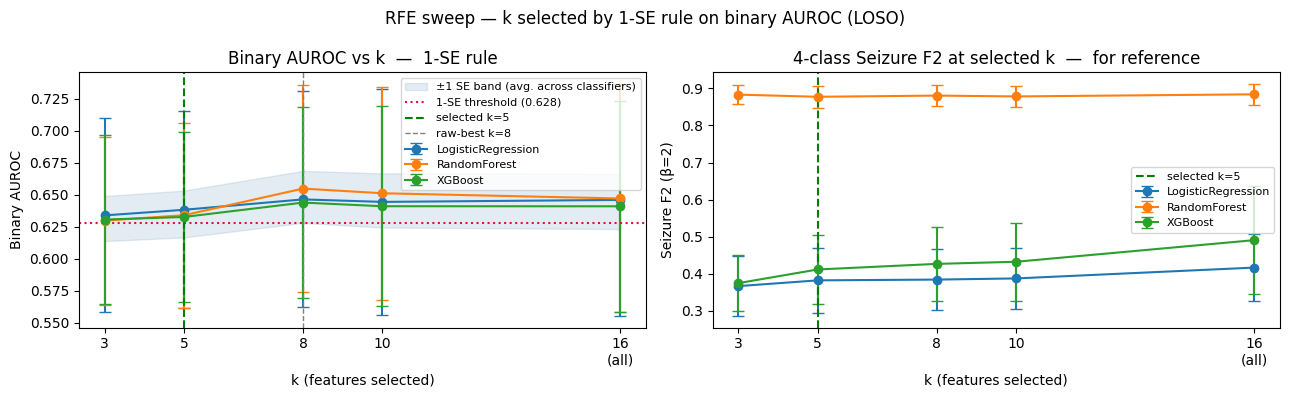


Feature selection frequency at k=5 (out of 15 folds):
  sampen                          ###############  (15/15)
  ampvar                          ###############  (15/15)
  corr_std                        ###############  (15/15)
  coherence_std                   ###############  (15/15)
  bandpower_delta                 #########        ( 9/15)
  linelength                      ######           ( 6/15)
  n_channels                                       ( 0/15)
  spike_count                                      ( 0/15)
  corr_max                                         ( 0/15)
  corr_mean                                        ( 0/15)
  coherence_max                                    ( 0/15)
  coherence_mean                                   ( 0/15)
  bandpower_theta                                  ( 0/15)
  bandpower_alpha                                  ( 0/15)
  bandpower_beta                                   ( 0/15)
  bandpower_gamma                                  ( 0/15)


In [55]:
rfe_estimator = LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs")

sweep_rows = []
sel_counts = {k: np.zeros(len(feature_cols), dtype=int) for k in K_VALUES}

for k in K_VALUES:
    k_label = "all" if k == len(feature_cols) else str(k)
    print(f"k={k_label}...", end=" ", flush=True)

    for train_idx, test_idx in logo.split(X, y_4class, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y2_tr, y2_te = y_binary[train_idx], y_binary[test_idx]
        y4_tr, y4_te = y_4class[train_idx], y_4class[test_idx]

        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_train)
        X_te_sc = scaler.transform(X_test)

        if k < len(feature_cols):
            rfe = RFE(estimator=clone(rfe_estimator), n_features_to_select=k)
            rfe.fit(X_tr_sc, y4_tr)
            X_tr_k = rfe.transform(X_tr_sc)
            X_te_k = rfe.transform(X_te_sc)
            sel_counts[k] += rfe.support_.astype(int)
        else:
            X_tr_k, X_te_k = X_tr_sc, X_te_sc
            sel_counts[k] += 1

        test_subject = groups[test_idx[0]]
        for clf_name, clf_proto in CLASSIFIERS.items():
            clf2 = clone(clf_proto)
            clf2.fit(X_tr_k, y2_tr)
            clf4 = clone(clf_proto)
            clf4.fit(X_tr_k, y4_tr)
            y2_pred = clf2.predict(X_te_k)
            y4_pred = clf4.predict(X_te_k)
            p2 = clf2.predict_proba(X_te_k)[:, 1]
            sweep_rows.append(
                {
                    "k": k,
                    "model": clf_name,
                    "test_subject": test_subject,
                    "auroc_2": roc_auc_score(y2_te, p2) if len(np.unique(y2_te)) > 1 else np.nan,
                    "sensitivity_2": recall_score(y2_te, y2_pred, pos_label=1, zero_division=0),
                    "f2_2": fbeta_score(y2_te, y2_pred, beta=2, pos_label=1, zero_division=0),
                    "sensitivity_4": recall_score(
                        y4_te, y4_pred, labels=[SEIZURE_CLASS], average=None, zero_division=0
                    )[0],
                    "f2_4": fbeta_score(
                        y4_te,
                        y4_pred,
                        beta=2,
                        labels=[SEIZURE_CLASS],
                        average=None,
                        zero_division=0,
                    )[0],
                }
            )

    print("done")

sweep_df = pd.DataFrame(sweep_rows)

# ── 1-SE rule on binary AUROC ─────────────────────────────────────────────────
# Average AUROC across classifiers per fold → one value per (k, fold)
# Then compute mean ± SE across folds for each k
auroc_per_fold = sweep_df.groupby(["k", "test_subject"])["auroc_2"].mean().reset_index()
auroc_stats = auroc_per_fold.groupby("k")["auroc_2"].agg(
    mean_auroc="mean", std_auroc="std", n="count"
)
auroc_stats["se"] = auroc_stats["std_auroc"] / np.sqrt(auroc_stats["n"])

best_mean = auroc_stats["mean_auroc"].max()
best_k_raw = int(auroc_stats["mean_auroc"].idxmax())
threshold = best_mean - auroc_stats.loc[best_k_raw, "se"]
BEST_K = max(MIN_K, int(auroc_stats[auroc_stats["mean_auroc"] >= threshold].index.min()))

print("\n1-SE rule on binary AUROC:")
print(f"  Peak mean AUROC : {best_mean:.4f}  at k={best_k_raw}")
print(f"  SE at peak      : {auroc_stats.loc[best_k_raw, 'se']:.4f}")
print(f"  Threshold       : {threshold:.4f}")
print(f"  1-SE candidate  : {int(auroc_stats[auroc_stats['mean_auroc'] >= threshold].index.min())}")
print(f"  Selected k      : {BEST_K}  (after MIN_K={MIN_K} floor)")

# ── Summary table ─────────────────────────────────────────────────────────────
sweep_agg = sweep_df.groupby(["model", "k"])[
    ["auroc_2", "sensitivity_2", "f2_2", "sensitivity_4", "f2_4"]
].agg(["mean", "std"])

for clf_name in CLASSIFIERS:
    print(f"\n{'=' * 80}\n  {clf_name}\n{'=' * 80}")
    print(f"  {'k':>5}   {'Binary AUROC':>18}   {'Sensitivity':>18}   {'F2 (β=2)':>18}")
    print("  " + "-" * 64)
    for k in K_VALUES:
        k_lab = "all" if k == len(feature_cols) else str(k)

        def _fmt(col):
            m = sweep_agg.loc[(clf_name, k), (col, "mean")]
            s = sweep_agg.loc[(clf_name, k), (col, "std")]
            return f"{m:.3f}+/-{s:.3f}"

        marker = (
            "  ◀ selected"
            if k == BEST_K
            else ("  ◀ raw best" if k == best_k_raw and best_k_raw != BEST_K else "")
        )
        print(
            f"  {k_lab:>5}   {_fmt('auroc_2'):>18}   {_fmt('sensitivity_2'):>18}"
            f"   {_fmt('f2_2'):>18}{marker}"
        )

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for clf_name in CLASSIFIERS:
    sub = sweep_df[sweep_df["model"] == clf_name].groupby("k")["auroc_2"]
    means, stds = sub.mean(), sub.std()
    ax.errorbar(means.index, means.values, yerr=stds.values, marker="o", label=clf_name, capsize=4)
ax.fill_between(
    auroc_stats.index,
    auroc_stats["mean_auroc"] - auroc_stats["se"],
    auroc_stats["mean_auroc"] + auroc_stats["se"],
    alpha=0.15,
    color="steelblue",
    label="±1 SE band (avg. across classifiers)",
)
ax.axhline(
    threshold,
    color="crimson",
    linestyle=":",
    linewidth=1.5,
    label=f"1-SE threshold ({threshold:.3f})",
)
ax.axvline(BEST_K, color="green", linestyle="--", linewidth=1.5, label=f"selected k={BEST_K}")
if best_k_raw != BEST_K:
    ax.axvline(
        best_k_raw, color="gray", linestyle="--", linewidth=1, label=f"raw-best k={best_k_raw}"
    )
ax.set_xlabel("k (features selected)")
ax.set_ylabel("Binary AUROC")
ax.set_title("Binary AUROC vs k  —  1-SE rule")
ax.set_xticks(K_VALUES)
ax.set_xticklabels([str(k) if k < len(feature_cols) else f"{k}\n(all)" for k in K_VALUES])
ax.legend(fontsize=8)

ax = axes[1]
for clf_name in CLASSIFIERS:
    sub = sweep_df[sweep_df["model"] == clf_name].groupby("k")["f2_4"]
    means, stds = sub.mean(), sub.std()
    ax.errorbar(means.index, means.values, yerr=stds.values, marker="o", label=clf_name, capsize=4)
ax.axvline(BEST_K, color="green", linestyle="--", linewidth=1.5, label=f"selected k={BEST_K}")
ax.set_xlabel("k (features selected)")
ax.set_ylabel("Seizure F2 (β=2)")
ax.set_title("4-class Seizure F2 at selected k  —  for reference")
ax.set_xticks(K_VALUES)
ax.set_xticklabels([str(k) if k < len(feature_cols) else f"{k}\n(all)" for k in K_VALUES])
ax.legend(fontsize=8)

plt.suptitle("RFE sweep — k selected by 1-SE rule on binary AUROC (LOSO)")
plt.tight_layout()
plt.show()

# ── Selected feature frequency ────────────────────────────────────────────────
if BEST_K < len(feature_cols):
    n_folds_total = logo.get_n_splits(X, y_4class, groups)
    print(f"\nFeature selection frequency at k={BEST_K} (out of {n_folds_total} folds):")
    sel_series = pd.Series(sel_counts[BEST_K], index=feature_cols).sort_values(ascending=False)
    for feat, cnt in sel_series.items():
        print(f"  {feat:30s}  {'#' * int(cnt):15s}  ({int(cnt):2d}/{n_folds_total})")

## 7. LOSO — main evaluation loop

This section runs the core cross-validation and stores all per-fold predictions for the 2 × 2
comparison in Section 8.

**Why Leave-One-Subject-Out?** Clinical seizure detection models must generalise to patients not seen
during training. LOSO is the most conservative (and realistic) evaluation strategy: each fold trains
on all subjects except one and tests on that held-out subject. With 15 subjects we get 15 folds,
each providing an unbiased estimate of out-of-patient performance.

**HMM post-processing — why Viterbi?** Raw classifier outputs are noisy: individual windows may
flip between classes even when the underlying state is stable. A Hidden Markov Model (HMM) smooths
this by enforcing temporal consistency via a learned transition matrix. Viterbi decoding finds the
globally most probable label sequence given the classifier's per-window probabilities, rather than
deciding each window independently.

**No data leakage in the HMM:** The transition matrix is estimated from the training-fold labels only
and applied to the test fold. This is critical — using the test labels to estimate transitions would
be a form of look-ahead leakage.

**Storing probabilities, not predictions:** The fold dictionary stores raw `predict_proba` outputs
rather than hard labels. This lets Section 8 apply both raw argmax and HMM decoding to the same
probability estimates, and compute AUROC which requires continuous scores.

**What runs next:** A short visualisation of the estimated HMM transition matrices confirms the
learned temporal structure before we proceed to scoring.

In [56]:
# ── HMM helpers ──────────────────────────────────────────────────────────────


def _estimate_log_trans(y_seq, n_classes, smooth=1.0):
    trans = np.full((n_classes, n_classes), smooth)
    for a, b in pairwise(y_seq):
        trans[a, b] += 1
    return np.log(trans / trans.sum(axis=1, keepdims=True))


def _viterbi(log_probs, log_trans, log_start):
    T, K = log_probs.shape
    dp = np.full((T, K), -np.inf)
    bp = np.zeros((T, K), dtype=int)
    dp[0] = log_start + log_probs[0]
    for t in range(1, T):
        scores = dp[t - 1, :, None] + log_trans
        bp[t] = scores.argmax(axis=0)
        dp[t] = scores.max(axis=0) + log_probs[t]
    path = np.empty(T, dtype=int)
    path[-1] = dp[-1].argmax()
    for t in range(T - 2, -1, -1):
        path[t] = bp[t + 1, path[t + 1]]
    return path


def _forward_backward(log_probs, log_trans, log_start):
    from scipy.special import logsumexp

    T, K = log_probs.shape
    # Forward: alpha[t,k] = log P(x_1..t, q_t=k)
    alpha = np.full((T, K), -np.inf)
    alpha[0] = log_start + log_probs[0]
    for t in range(1, T):
        alpha[t] = logsumexp(alpha[t - 1, :, None] + log_trans, axis=0) + log_probs[t]
    # Backward: beta[t,k] = log P(x_{t+1}..T | q_t=k)
    beta = np.zeros((T, K))
    for t in range(T - 2, -1, -1):
        beta[t] = logsumexp(log_trans + (log_probs[t + 1] + beta[t + 1]), axis=1)
    # Posterior: gamma[t,k] = P(q_t=k | x_1..T)
    log_gamma = alpha + beta
    log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
    return np.exp(log_gamma)


def hmm_smooth(y_train, file_stems_test, y_prob_test, n_classes):
    log_trans = _estimate_log_trans(y_train, n_classes)
    counts = np.bincount(y_train, minlength=n_classes)
    log_start = np.log(counts / counts.sum() + 1e-10)
    y_hmm = np.empty(len(file_stems_test), dtype=int)
    for stem in np.unique(file_stems_test):
        mask = file_stems_test == stem
        log_e = np.log(y_prob_test[mask] + 1e-10)
        y_hmm[mask] = _viterbi(log_e, log_trans, log_start)
    return y_hmm


def hmm_forward_backward(y_train, file_stems_test, y_prob_test, n_classes):
    log_trans = _estimate_log_trans(y_train, n_classes)
    counts = np.bincount(y_train, minlength=n_classes)
    log_start = np.log(counts / counts.sum() + 1e-10)
    posteriors = np.empty((len(file_stems_test), n_classes))
    for stem in np.unique(file_stems_test):
        mask = file_stems_test == stem
        log_e = np.log(y_prob_test[mask] + 1e-10)
        posteriors[mask] = _forward_backward(log_e, log_trans, log_start)
    return posteriors


# ── LOSO loop ─────────────────────────────────────────────────────────────────

stored_folds = []
n_folds = logo.get_n_splits(X, y_binary, groups)
k_label = BEST_K if BEST_K < len(feature_cols) else "all"
print(f"Running LOSO  (k={k_label},  {n_folds} folds) ...")

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y_binary, groups), start=1):
    test_subject = groups[test_idx[0]]
    X_train, X_test = X[train_idx], X[test_idx]
    y2_tr, y2_te = y_binary[train_idx], y_binary[test_idx]
    y4_tr, y4_te = y_4class[train_idx], y_4class[test_idx]

    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    if BEST_K < len(feature_cols):
        rfe = RFE(estimator=clone(rfe_estimator), n_features_to_select=BEST_K)
        rfe.fit(X_tr_sc, y4_tr)
        X_tr_k = rfe.transform(X_tr_sc)
        X_te_k = rfe.transform(X_te_sc)
    else:
        X_tr_k, X_te_k = X_tr_sc, X_te_sc

    fold = {
        "fold": fold_idx,
        "test_subject": test_subject,
        "y_true_2": y2_te,
        "y_true_4": y4_te,
        "y_train_2": y2_tr,
        "y_train_4": y4_tr,
        "file_stems": file_stems[test_idx],
        "window_mid_s": window_mid_s[test_idx],
        "probs_2": {},
        "probs_4": {},
    }

    for clf_name, clf_proto in CLASSIFIERS.items():
        clf2 = clone(clf_proto)
        clf2.fit(X_tr_k, y2_tr)
        fold["probs_2"][clf_name] = clf2.predict_proba(X_te_k)

        clf4 = clone(clf_proto)
        clf4.fit(X_tr_k, y4_tr)
        fold["probs_4"][clf_name] = clf4.predict_proba(X_te_k)

    stored_folds.append(fold)
    if fold_idx % 5 == 0 or fold_idx == n_folds:
        print(f"  fold {fold_idx}/{n_folds}  ({test_subject})")

print("\nLOSO complete.")

Running LOSO  (k=5,  15 folds) ...
  fold 5/15  (ID13)
  fold 10/15  (ID4)
  fold 15/15  (ID9)

LOSO complete.


 ## 7b. HMM transition matrices — sanity check

Before interpreting the smoothed predictions it is worth inspecting what temporal structure the HMM
has learned.

**What to look for:**

- **Binary matrix:** The diagonal entries should be close to 1 — seizures and non-seizures each
  persist for many consecutive windows (minutes), so self-transitions dominate. An off-diagonal
  value close to 0.5 would suggest the model sees rapid flickering between states, which would
  indicate a problem with the labelling or a very short seizure duration relative to the window size.
- **4-class matrix:** The transition `non_seizure → pre_seizure`, `pre_seizure → seizure`,
  `seizure → post_seizure`, and `post_seizure → non_seizure` should be the only notable
  off-diagonal entries, and they should appear roughly symmetrically for onset and offset.
  High `seizure → non_seizure` directly (skipping post) would suggest the 30 s post-ictal zone
  is too narrow relative to the actual recording dynamics.

**Important:** This matrix is estimated from the full dataset labels (all subjects combined) purely
for visualisation. The HMM used in the actual LOSO evaluation is re-estimated per fold from training
labels only.

**What runs next:** Section 8 scores all four configurations (binary/4-class × raw/HMM) across all
folds and produces the summary comparison table and bar charts.

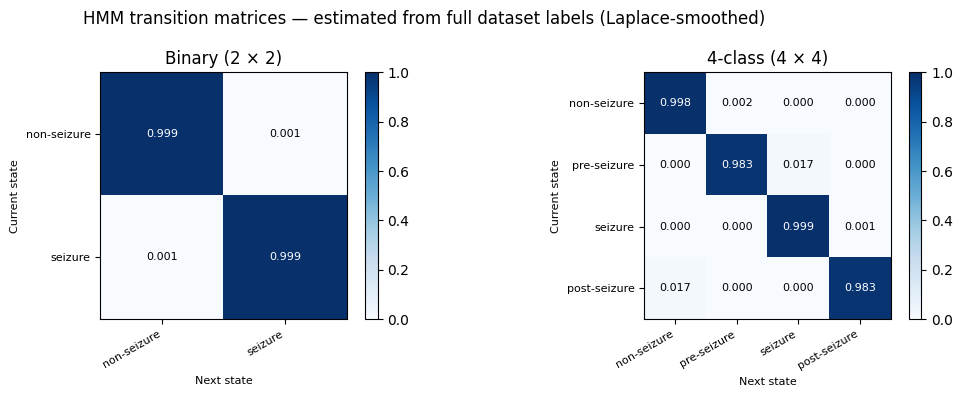

In [57]:
trans_2 = np.exp(_estimate_log_trans(y_binary, n_classes=2))
trans_4 = np.exp(_estimate_log_trans(y_4class, n_classes=4))

labels_2 = ["non-seizure", "seizure"]
labels_4 = ["non-seizure", "pre-seizure", "seizure", "post-seizure"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, trans, labels, title in [
    (axes[0], trans_2, labels_2, "Binary (2x2)"),
    (axes[1], trans_4, labels_4, "4-class (4x4)"),
]:
    n = len(labels)
    im = ax.imshow(trans, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(n))
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(n))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Next state", fontsize=8)
    ax.set_ylabel("Current state", fontsize=8)
    ax.set_title(title)
    for i in range(n):
        for j in range(n):
            ax.text(
                j,
                i,
                f"{trans[i, j]:.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if trans[i, j] > 0.6 else "black",
            )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("HMM transition matrices — estimated from full dataset labels (Laplace-smoothed)")
plt.tight_layout()
plt.show()

## 8. Results — 2 × 2 comparison

The clinical goal drives the metric choice: missing a seizure is far more costly than a false alarm,
so sensitivity (seizure recall) is the primary measure.

| Metric | Formula | Why it is used |
|--------|---------|----------------|
| **Sensitivity** | TP / (TP + FN) | Directly measures the fraction of seizures caught; the primary clinical metric |
| **F2 (β=2)** | (5·P·R) / (4·P + R) | Rewards high recall but still penalises a model that fires on everything; β=2 weights recall twice over precision |
| **AUROC** | Area under ROC curve | Threshold-free ranking quality; computed from raw probabilities so it is the same for Raw and HMM rows |

**How to read the results:**

- **Sensitivity near 1.0** is the goal. A value of 0.95 means 5 % of seizure windows were missed.
- **F2** contextualises whether high sensitivity comes at a reasonable precision cost. A model with
  sensitivity = 1.0 and F2 = 0.5 is flagging non-seizure windows heavily; one with F2 = 0.9 has
  found a better balance.
- **Raw vs HMM:** If sensitivity drops with HMM, the smoother is suppressing true ictal detections
  — the transition matrix may have too-strong non-seizure self-transitions for short seizures.
- **Binary vs 4-class:** The 4-class model's sensitivity is measured only on the seizure class
  (index 2 in CLASS_ORDER), making it directly comparable to the binary result.
- **High per-subject variance** (large ±) is common in cross-patient iEEG — some patients' seizures
  are simply harder to detect from scalp/intracranial features alone.

**What runs next:** Section 9 visualises the actual time-series predictions per seizure file,
which helps diagnose where and why sensitivity is lost.


  LogisticRegression
  Setting                 Sensitivity (Seizure Recall)  F2 (beta=2)                   AUROC                       
  --------------------------------------------------------------------------------------
  Binary / Raw            0.490 +/- 0.072                 0.523 +/- 0.069                 0.638 +/- 0.077               
  Binary / HMM            0.486 +/- 0.122                 0.523 +/- 0.116                 0.638 +/- 0.077               
  Binary / FB             0.483 +/- 0.118                 0.519 +/- 0.112                 0.668 +/- 0.101               
  4-class / Raw           0.340 +/- 0.085                 0.382 +/- 0.088                 0.649 +/- 0.075               
  4-class / HMM           0.377 +/- 0.121                 0.418 +/- 0.122                 0.649 +/- 0.075               
  4-class / FB            0.375 +/- 0.121                 0.416 +/- 0.122                 0.680 +/- 0.077               

  RandomForest
  Setting                 Sensit

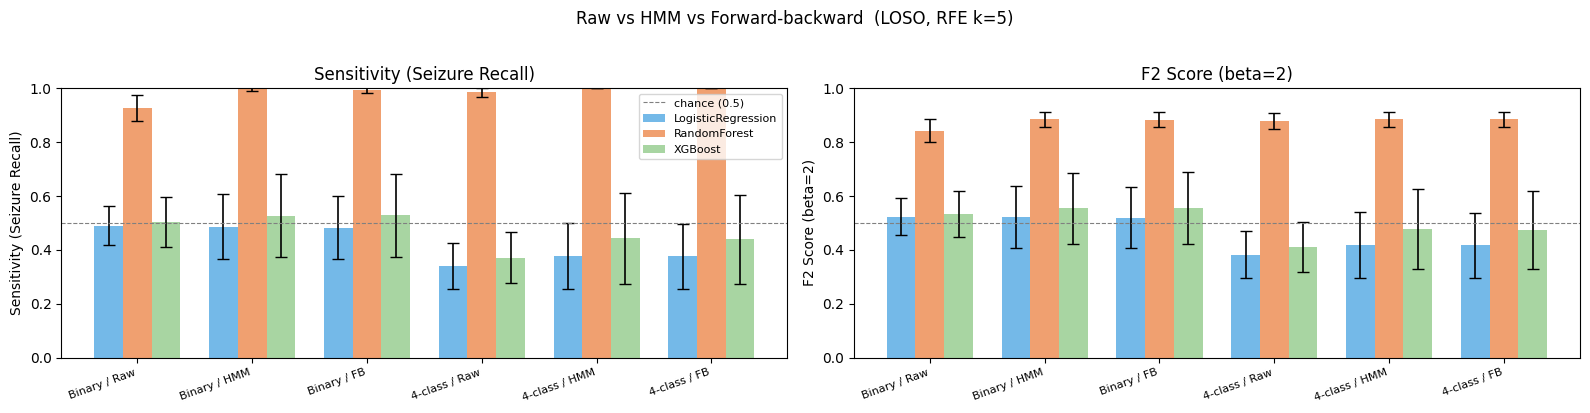

In [58]:
# mode: "raw" = argmax of classifier probs
#        "hmm" = Viterbi (HMM hard labels)
#        "fb"  = Forward-backward posteriors (argmax for hard metrics; posteriors for AUROC)
SETTINGS = [
    ("Binary / Raw", 2, "raw"),
    ("Binary / HMM", 2, "hmm"),
    ("Binary / FB", 2, "fb"),
    ("4-class / Raw", 4, "raw"),
    ("4-class / HMM", 4, "hmm"),
    ("4-class / FB", 4, "fb"),
]
SETTING_ORDER = [s[0] for s in SETTINGS]


def compute_metrics(folds):
    rows = []
    for clf_name in CLASSIFIERS:
        for fold in folds:
            for label, n_cls, mode in SETTINGS:
                probs = fold["probs_2" if n_cls == 2 else "probs_4"][clf_name]
                y_true = fold["y_true_2" if n_cls == 2 else "y_true_4"]
                y_tr = fold["y_train_2" if n_cls == 2 else "y_train_4"]
                present = np.unique(y_true)

                if mode == "hmm":
                    y_pred = hmm_smooth(y_tr, fold["file_stems"], probs, n_cls)
                    probs_auc = probs
                elif mode == "fb":
                    fb = hmm_forward_backward(y_tr, fold["file_stems"], probs, n_cls)
                    y_pred = fb.argmax(axis=1)
                    probs_auc = fb
                else:
                    y_pred = probs.argmax(axis=1)
                    probs_auc = probs

                if n_cls == 2:
                    sensitivity = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
                    f2 = fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0)
                    auc = roc_auc_score(y_true, probs_auc[:, 1]) if len(present) > 1 else np.nan
                else:
                    sensitivity = recall_score(
                        y_true, y_pred, labels=[SEIZURE_CLASS], average=None, zero_division=0
                    )[0]
                    f2 = fbeta_score(
                        y_true,
                        y_pred,
                        beta=2,
                        labels=[SEIZURE_CLASS],
                        average=None,
                        zero_division=0,
                    )[0]
                    auc = (
                        roc_auc_score(y_true, probs_auc, multi_class="ovr", average="macro")
                        if len(present) == n_cls
                        else np.nan
                    )

                rows.append(
                    {
                        "classifier": clf_name,
                        "setting": label,
                        "sensitivity": sensitivity,
                        "f2": f2,
                        "roc_auc": auc,
                    }
                )
    return (
        pd.DataFrame(rows)
        .groupby(["classifier", "setting"])[["sensitivity", "f2", "roc_auc"]]
        .agg(["mean", "std"])
    )


agg = compute_metrics(stored_folds)

# Table
METRIC_LABELS = {
    "sensitivity": "Sensitivity (Seizure Recall)",
    "f2": "F2 (beta=2)",
    "roc_auc": "AUROC",
}
for clf_name in CLASSIFIERS:
    print(f"\n{'=' * 74}\n  {clf_name}\n{'=' * 74}")
    print(f"  {'Setting':<22}" + "".join(f"  {v:<28}" for v in METRIC_LABELS.values()))
    print("  " + "-" * 86)
    for s in SETTING_ORDER:
        row = f"  {s:<22}"
        for m in METRIC_LABELS:
            try:
                mu = agg.loc[(clf_name, s), (m, "mean")]
                sd = agg.loc[(clf_name, s), (m, "std")]
                row += f"  {mu:.3f} +/- {sd:.3f}               "
            except KeyError:
                row += f"  {'N/A':<28}"
        print(row)
print("\n* For FB rows, AUROC uses forward-backward posteriors (not raw classifier probs).")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=False)
x = np.arange(len(SETTING_ORDER))
bar_width = 0.25
n_clfs = len(CLASSIFIERS)
offsets = np.linspace(-(n_clfs - 1) * bar_width / 2, (n_clfs - 1) * bar_width / 2, n_clfs)
clf_colors = {"LogisticRegression": "#74b9e8", "RandomForest": "#f0a070", "XGBoost": "#a8d5a2"}
for ax, metric, nice in zip(
    axes, ["sensitivity", "f2"], ["Sensitivity (Seizure Recall)", "F2 Score (beta=2)"], strict=True
):
    for offset, clf_name in zip(offsets, CLASSIFIERS, strict=True):
        means = [agg.loc[(clf_name, s), (metric, "mean")] for s in SETTING_ORDER]
        stds = [agg.loc[(clf_name, s), (metric, "std")] for s in SETTING_ORDER]
        ax.bar(
            x + offset,
            means,
            bar_width,
            yerr=stds,
            capsize=4,
            color=clf_colors[clf_name],
            label=clf_name,
            error_kw={"elinewidth": 1.2},
        )
    ax.set_xticks(x)
    ax.set_xticklabels(SETTING_ORDER, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel(nice)
    ax.set_title(nice)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="chance (0.5)")
    if ax is axes[0]:
        ax.legend(fontsize=8)

k_str = str(BEST_K) if BEST_K < len(feature_cols) else "all"
plt.suptitle(f"Raw vs HMM vs Forward-backward  (LOSO, RFE k={k_str})", y=1.02)
plt.tight_layout()
plt.show()

P## 9. Time-series visualisation of predictions

Aggregate metrics can hide important patterns. This section plots the full timeline of each seizure
file for the first `N_SUBJECTS_PLOT` subjects, stacking six label tracks on a shared time axis.

| Row | Content | What to look for |
|-----|---------|-----------------|
| 1 | Binary — ground truth | The expected seizure segment (red) between two non-seizure blocks (blue) |
| 2 | Binary — P(class) | Probability curves; a confident model shows a sharp step from ≈0 to ≈1 at onset |
| 3 | Binary — HMM | Whether HMM smooths out mid-seizure dips or onset/offset transients |
| 4 | 4-class — ground truth | Pre/post zones (orange/purple) bracketing the ictal core |
| 5 | 4-class — P(class) | Whether the classifier produces meaningful probability mass on pre/post classes |
| 6 | 4-class — HMM | Whether the Viterbi path respects the expected non→pre→ictal→post→non ordering |

**Common failure patterns to watch for:**

- **False positives in the non-seizure margins** — the 3-min boundary is sharp in the labels but
  brain activity transitions gradually; false positives near the margins may reflect true peri-ictal
  activity rather than model error.
- **Fragmented predictions** — if the raw classifier (rows 2/5) shows rapid oscillations, the HMM
  (rows 3/6) should stabilise them. If it does not, the transition matrix may have too-high
  self-transition probabilities.
- **Skipped pre/post classes** — in the 4-class HMM track, jumping directly from non-seizure to
  seizure without passing through pre-seizure suggests the transition zone is too short or the
  classifier has low confidence in the pre-seizure class.

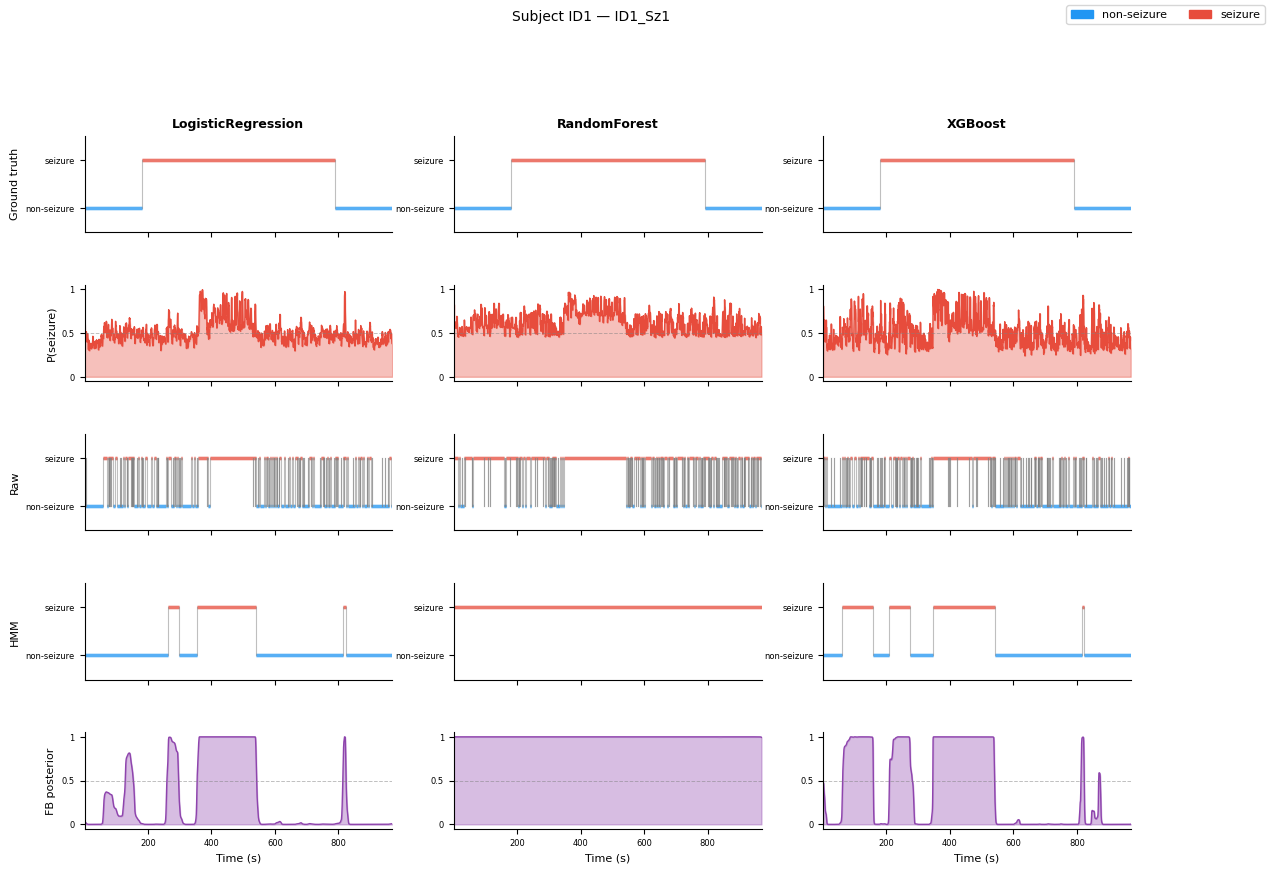

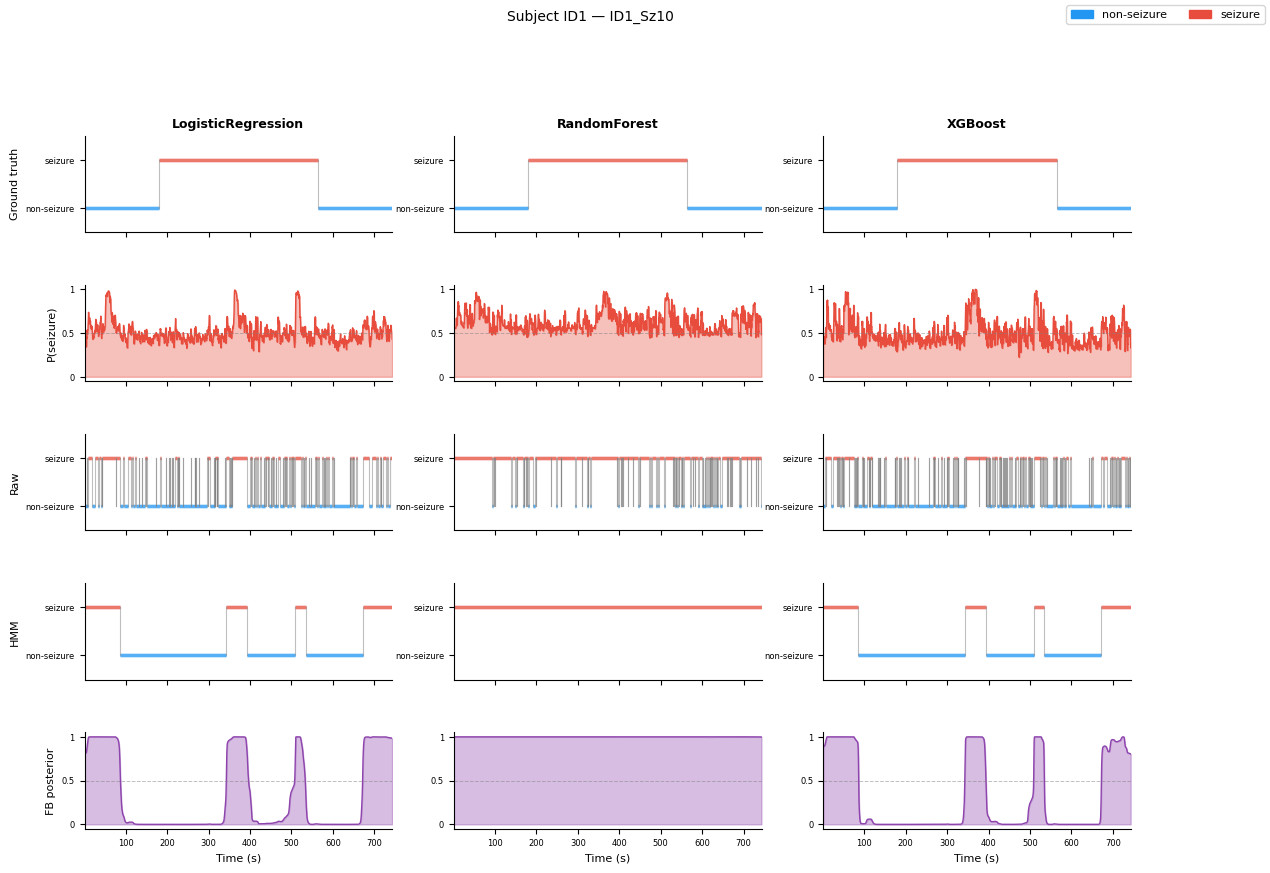

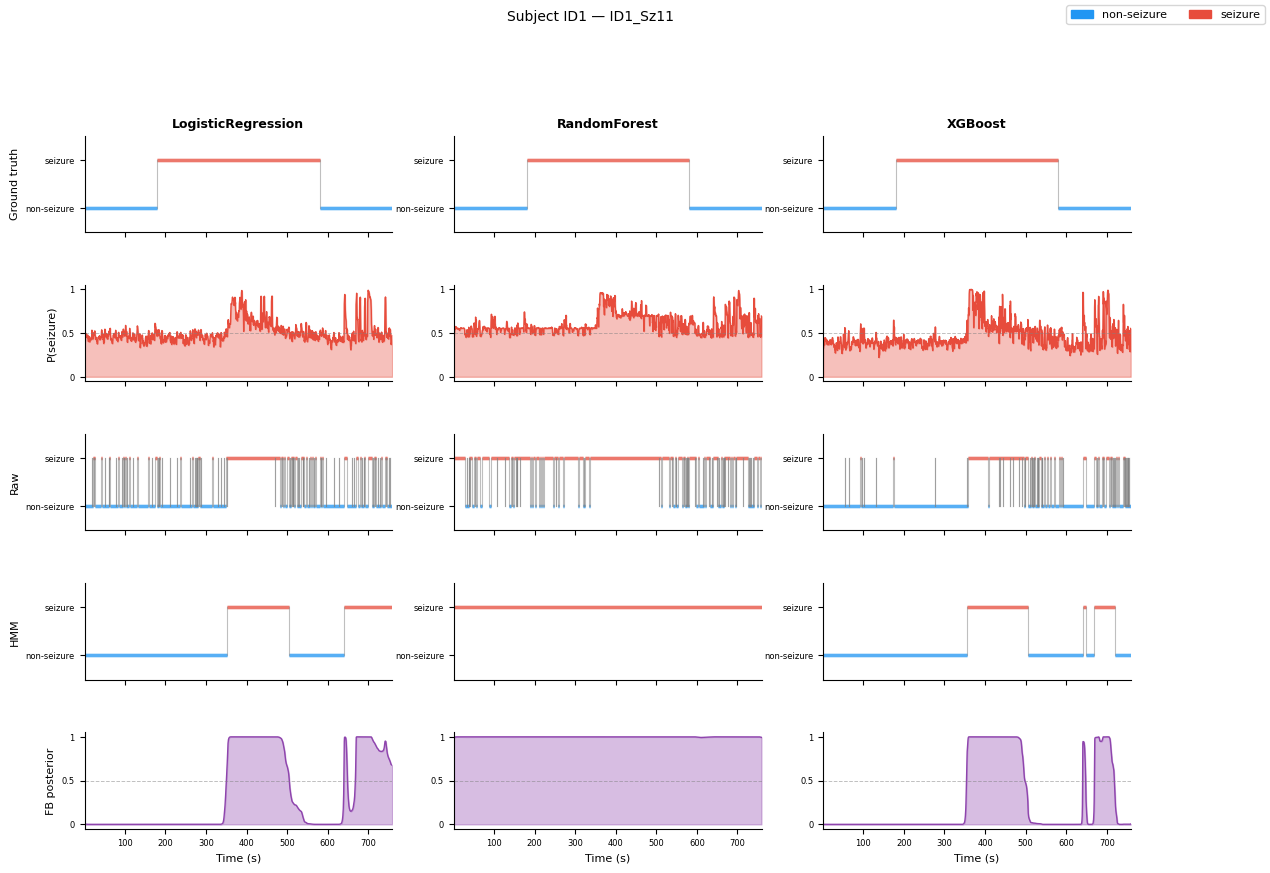

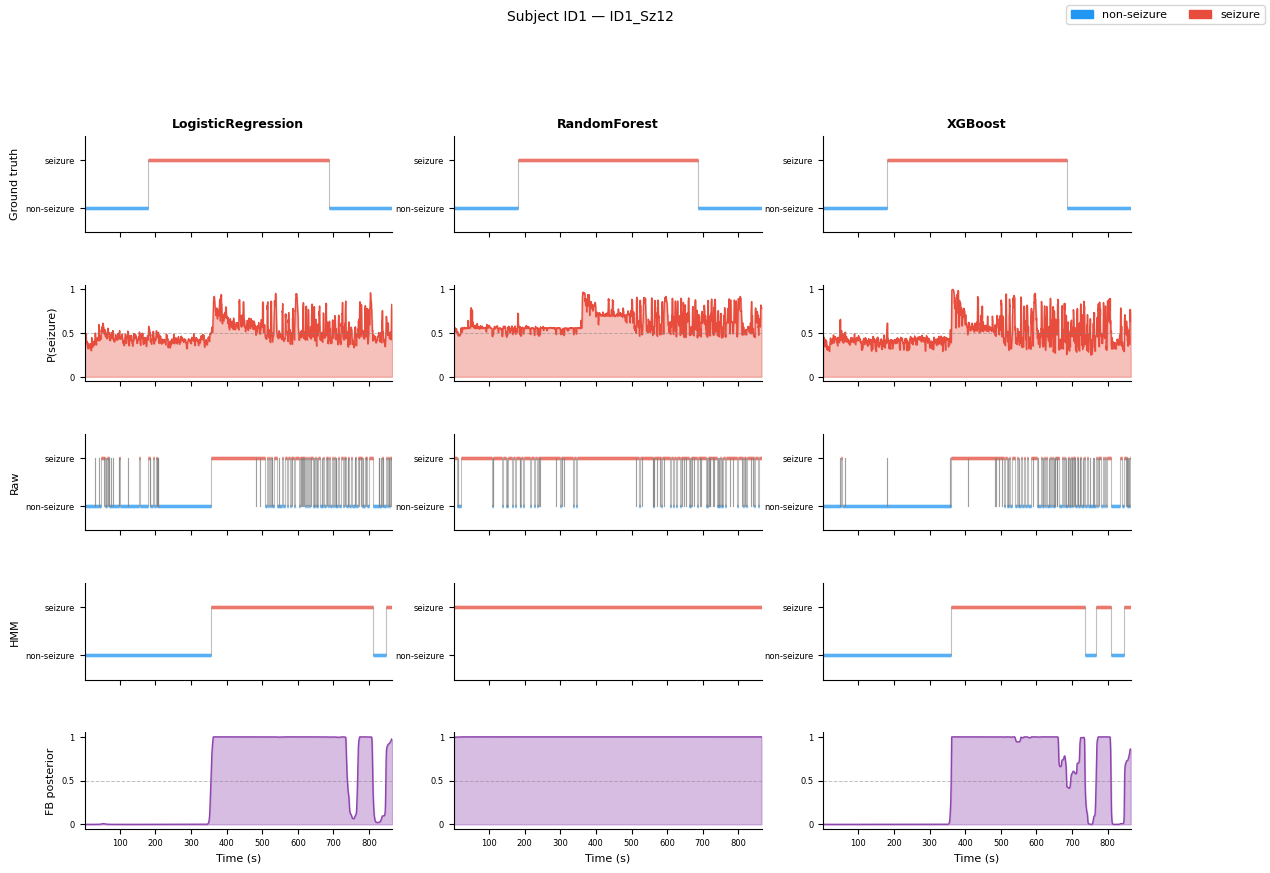

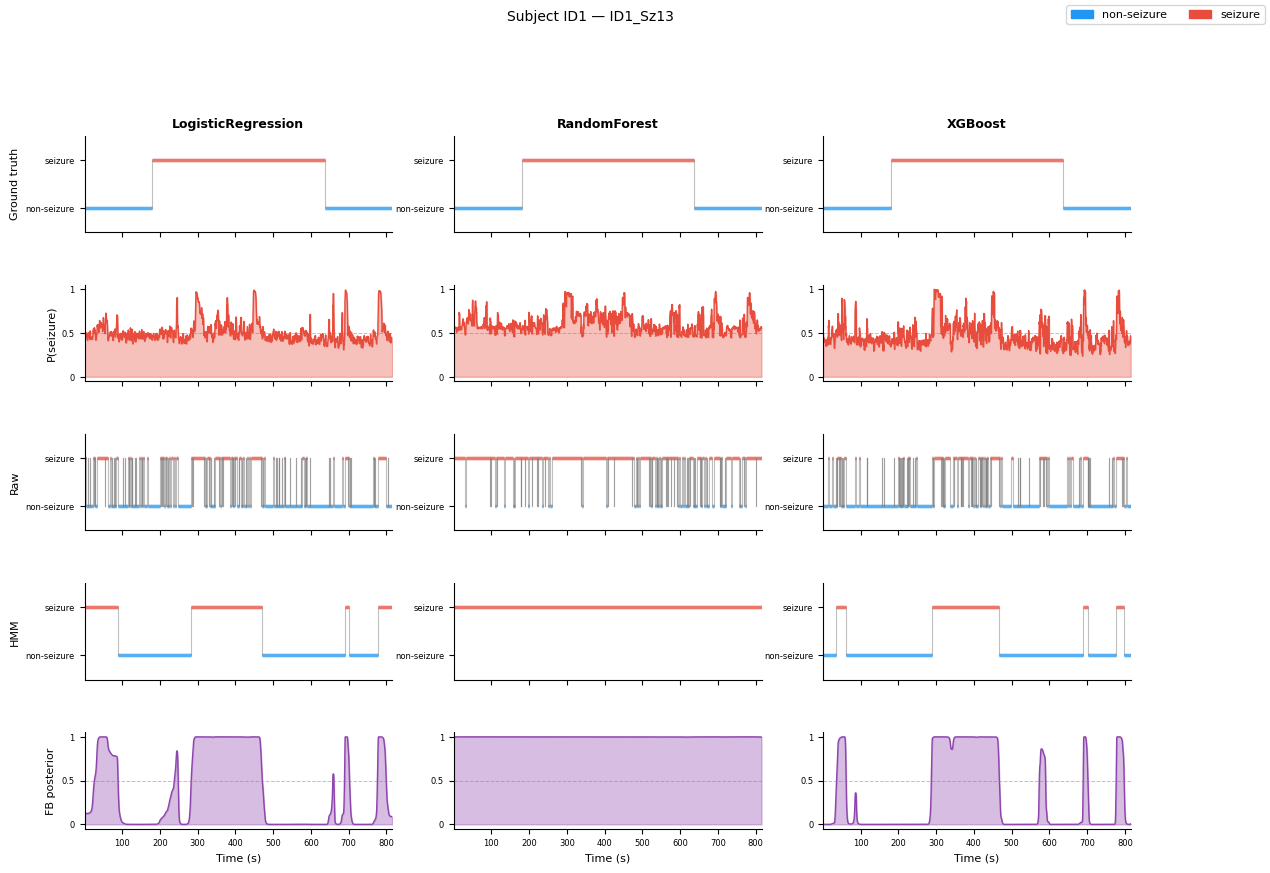

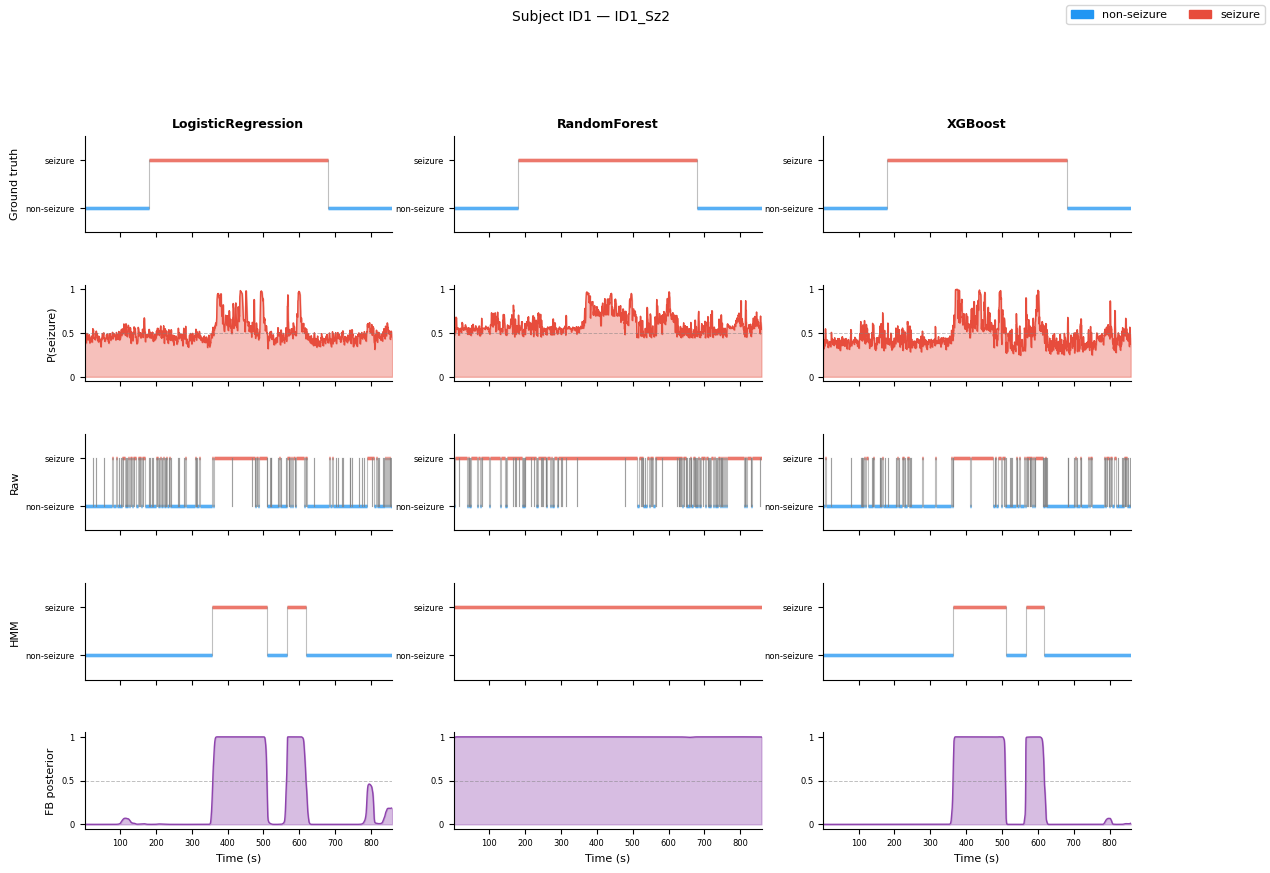

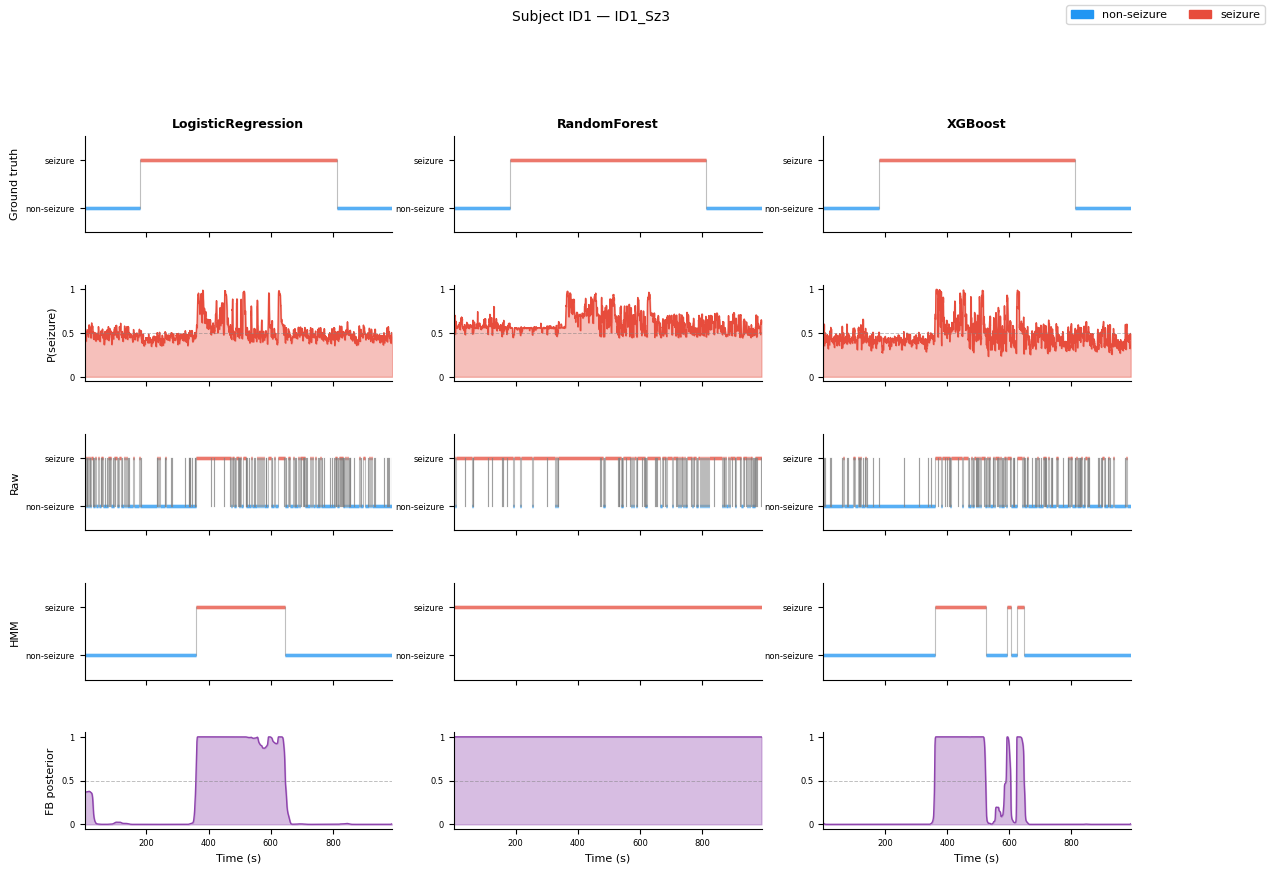

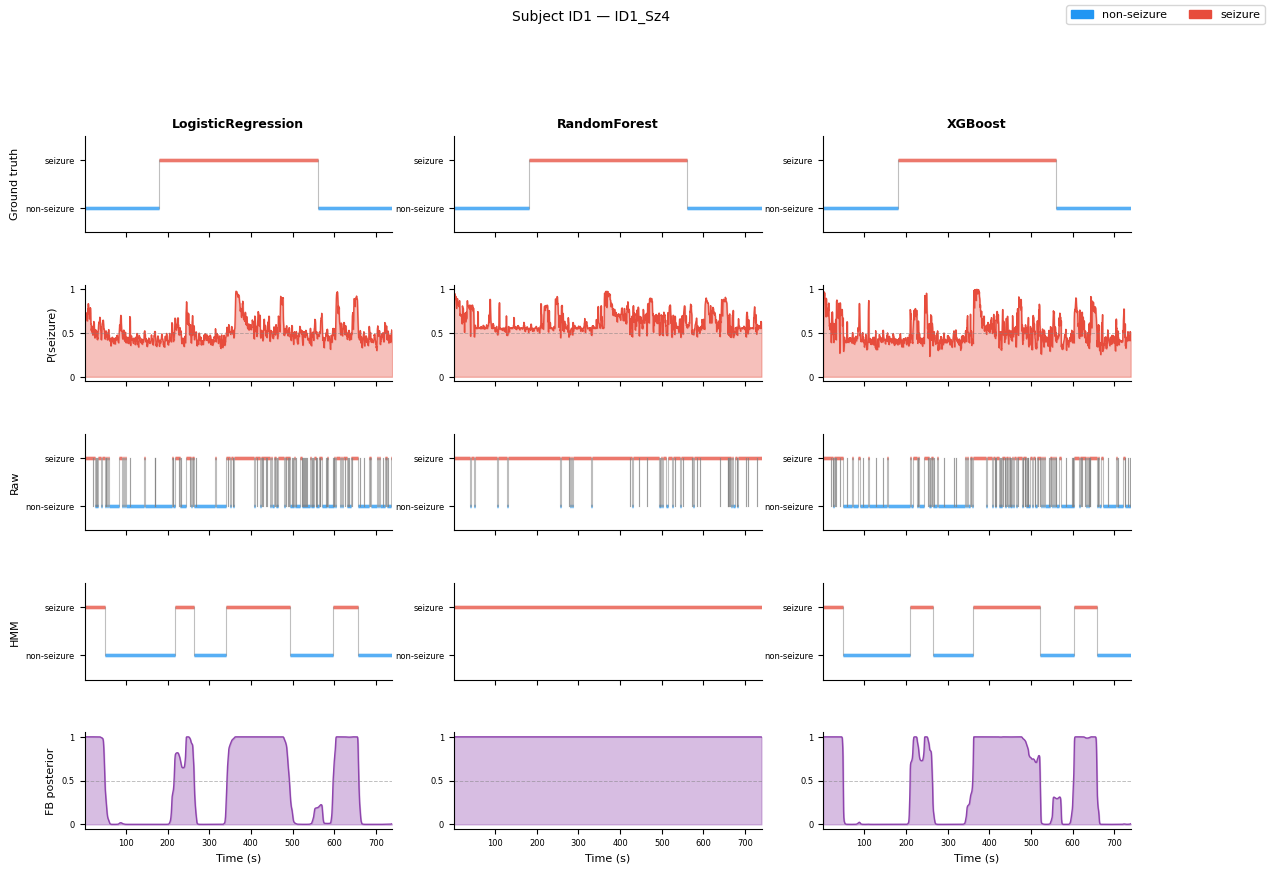

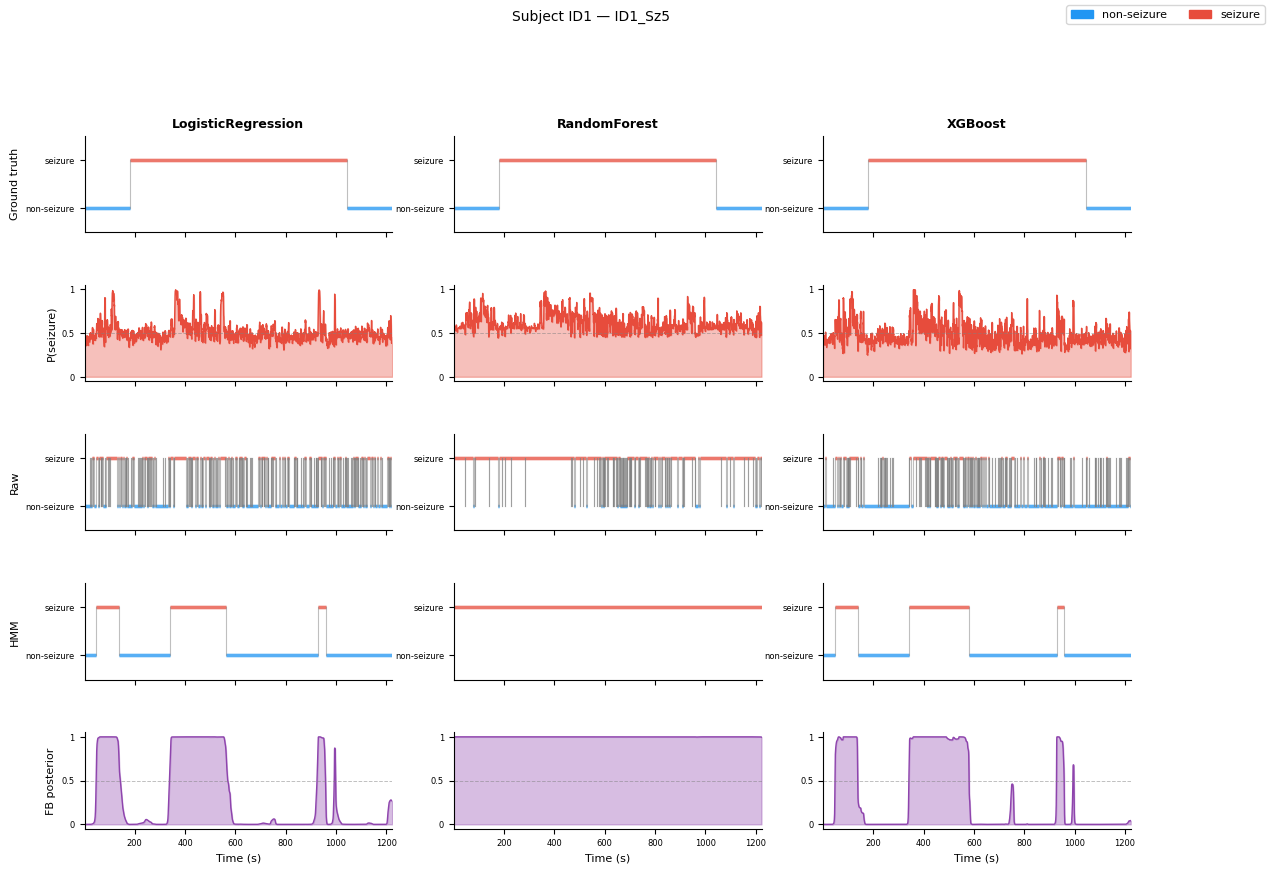

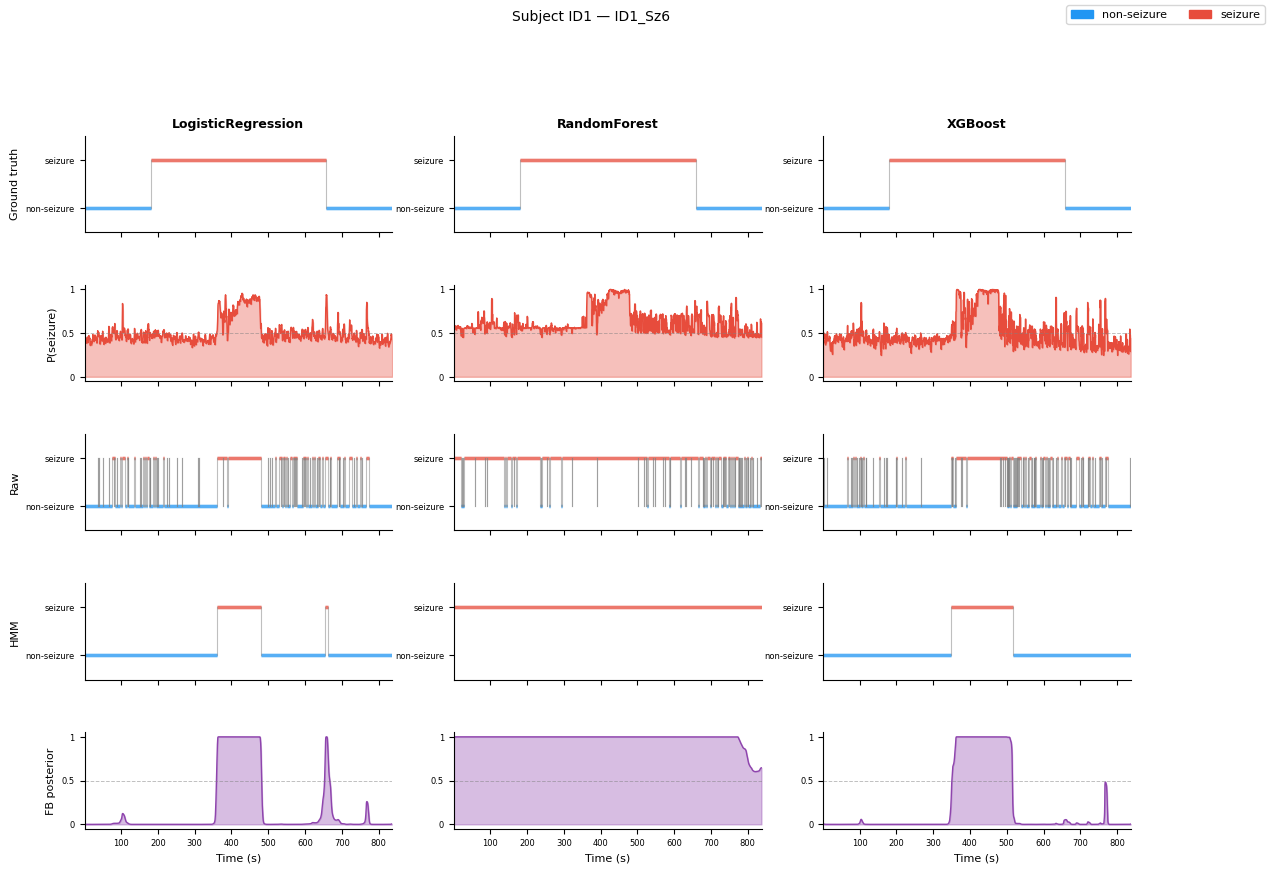

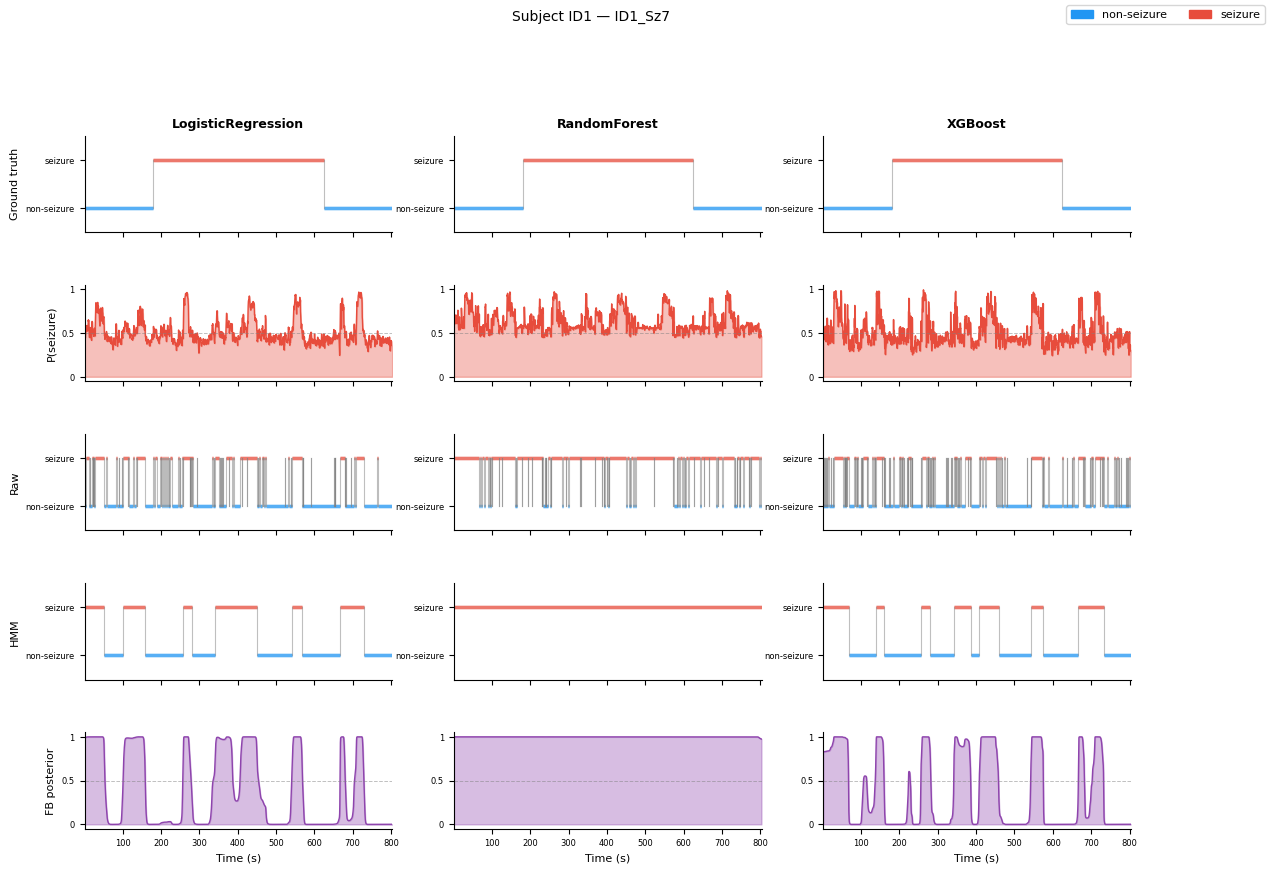

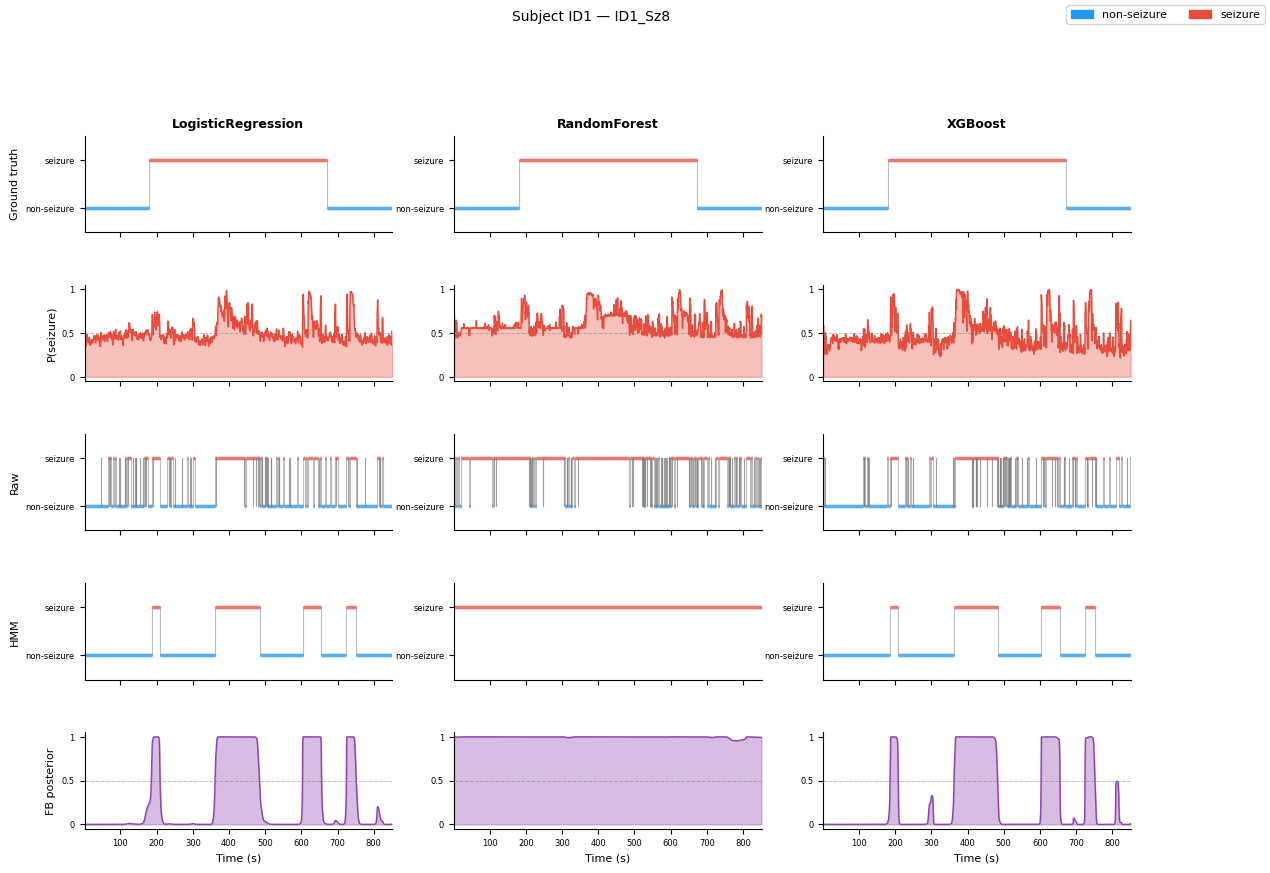

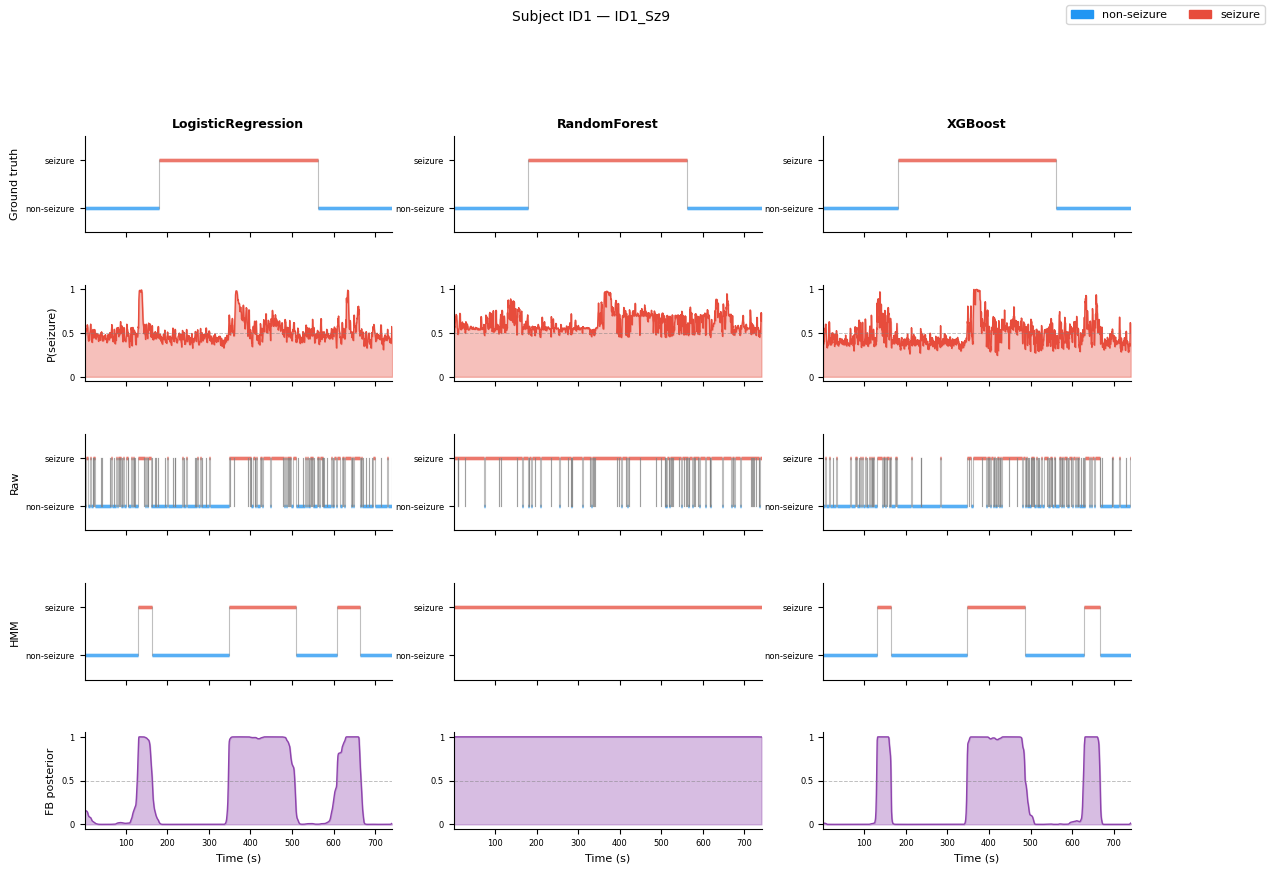

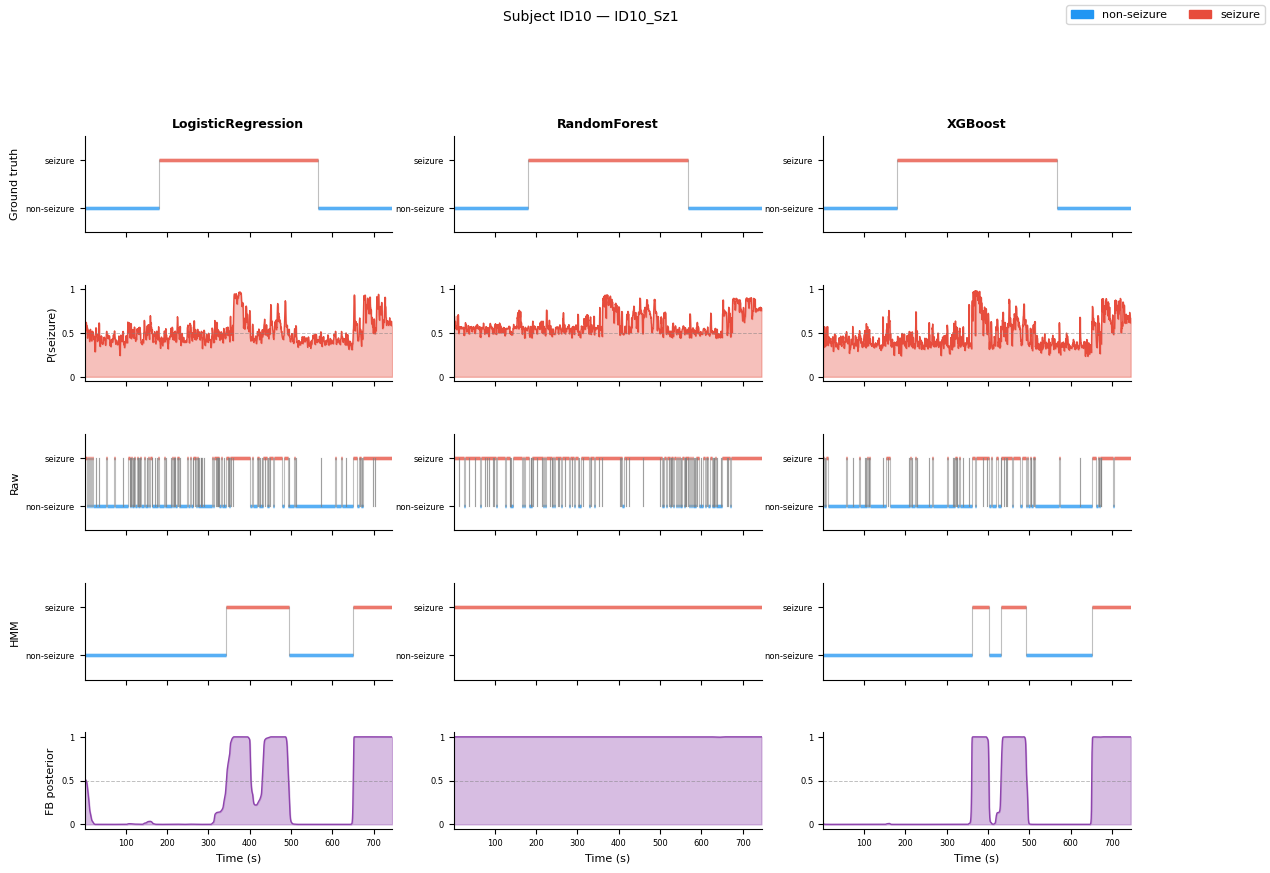

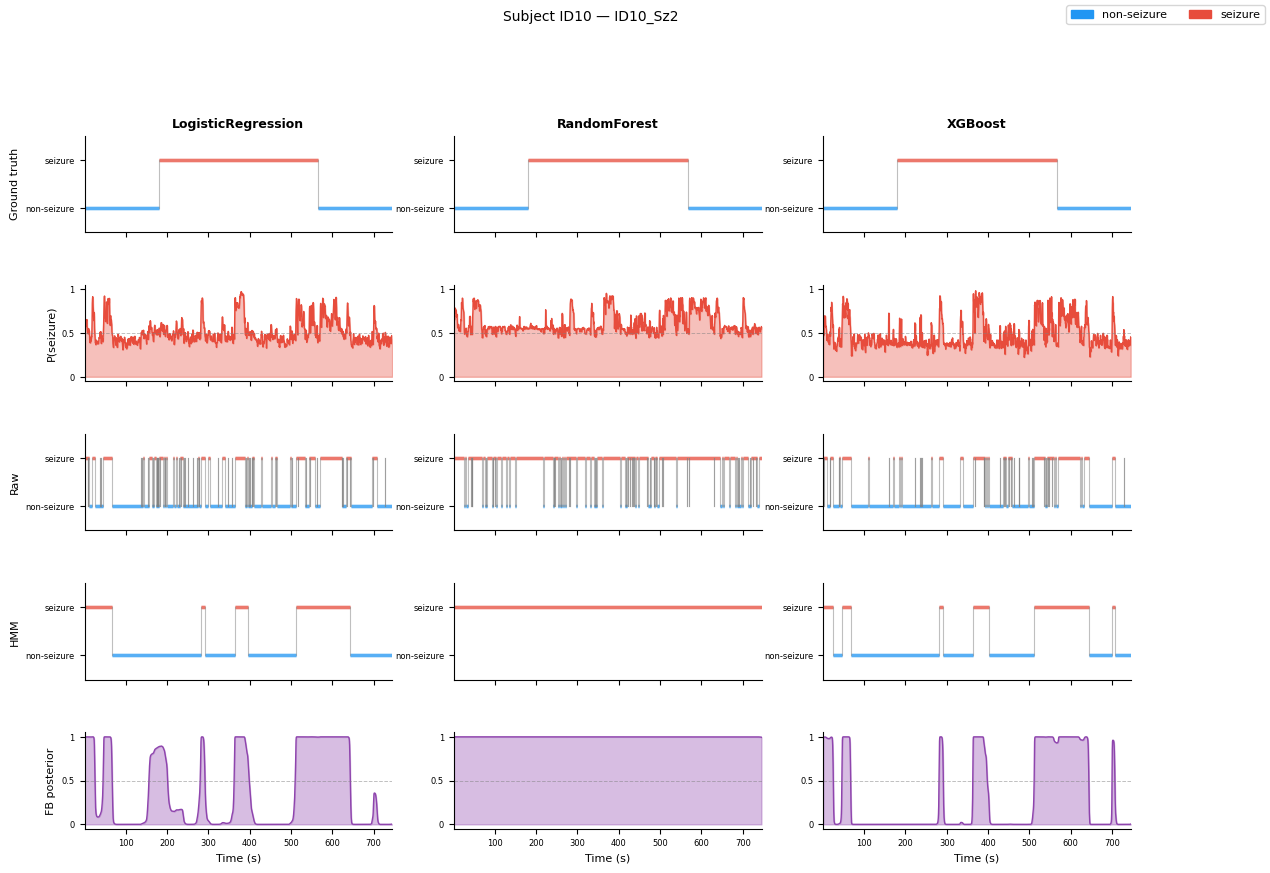

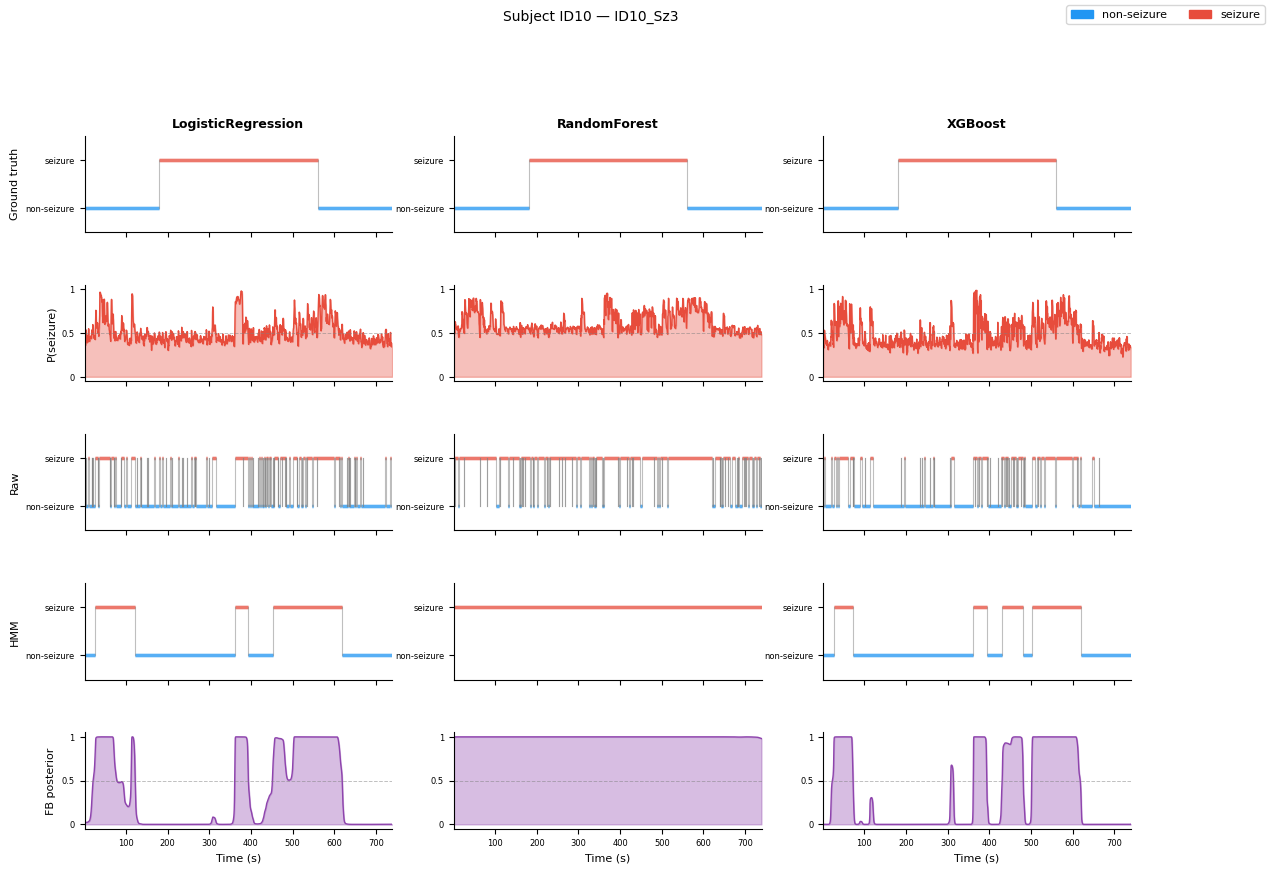

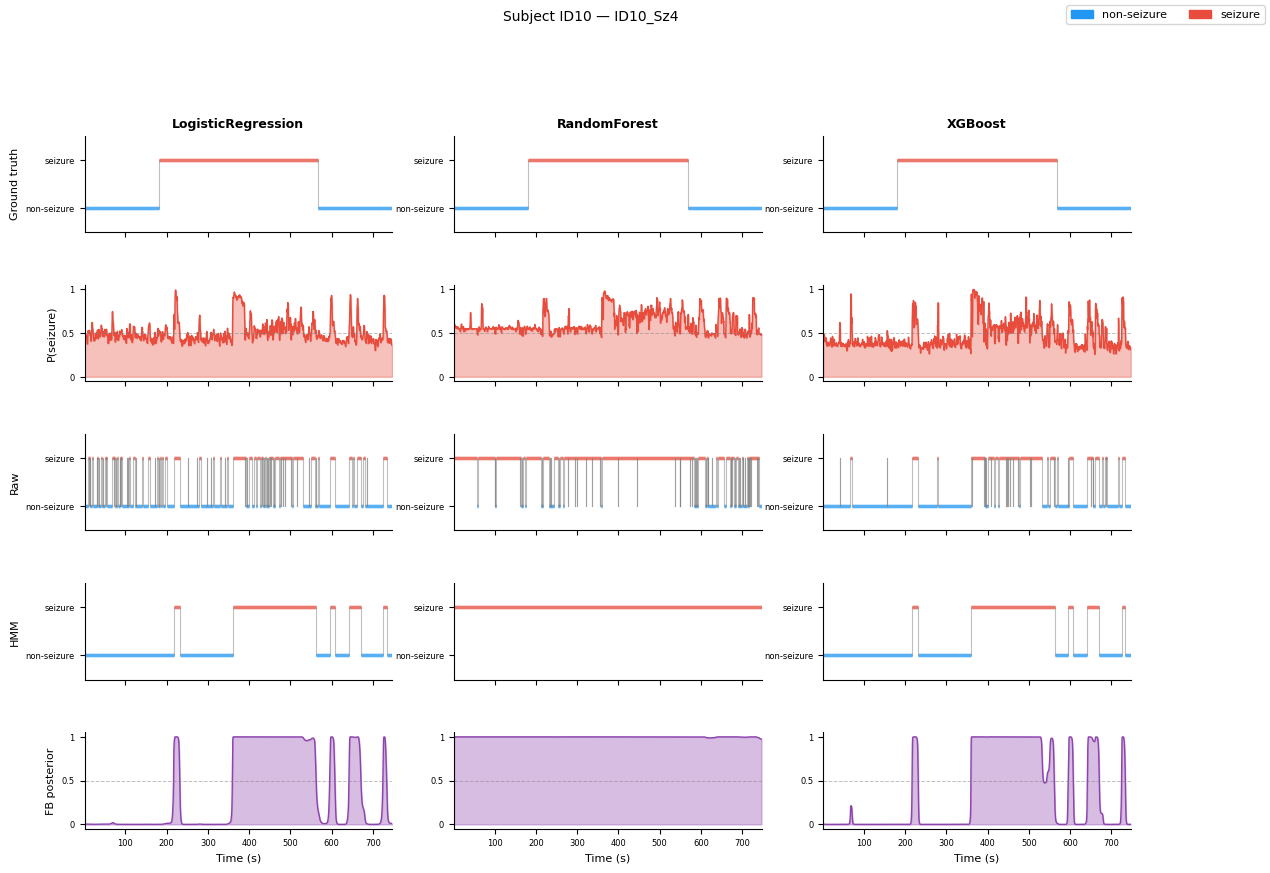

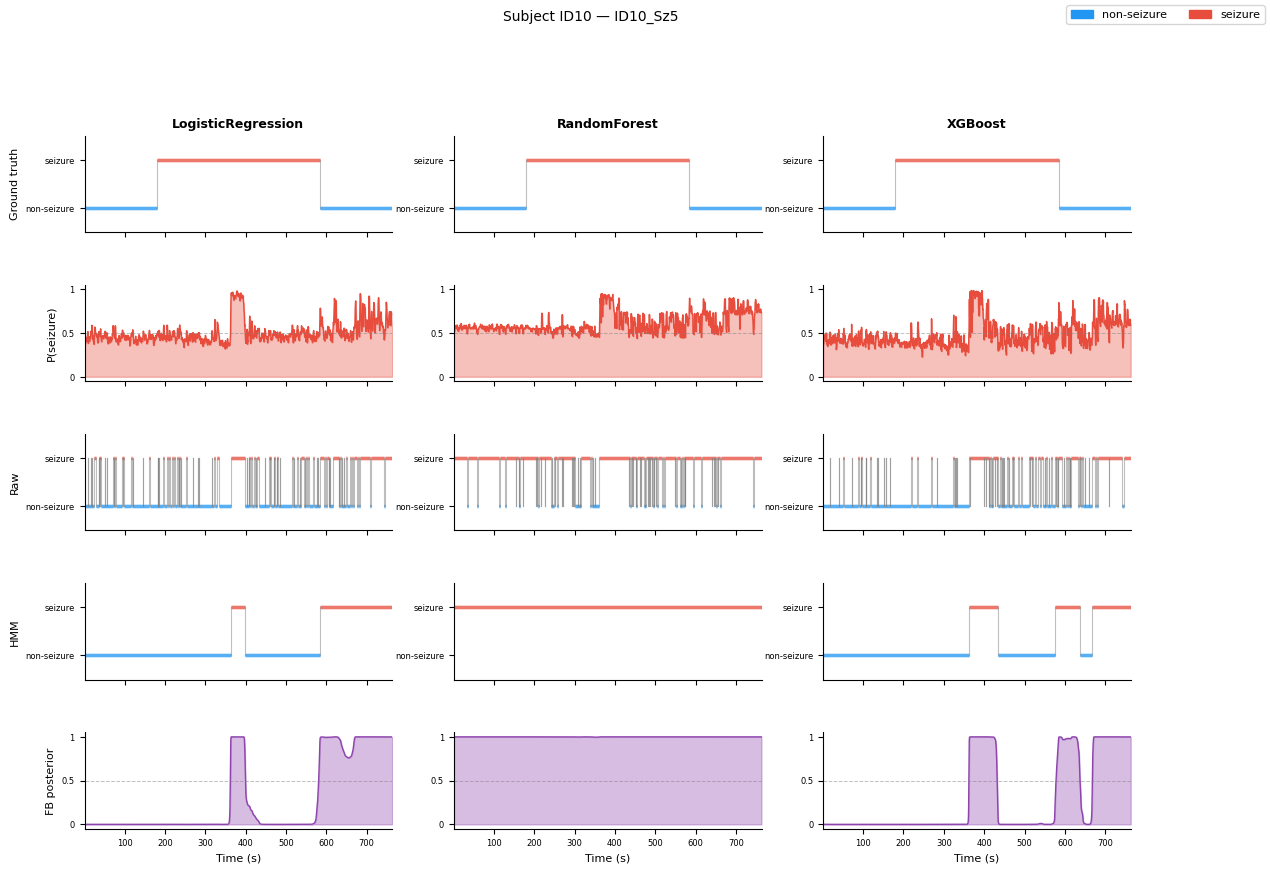

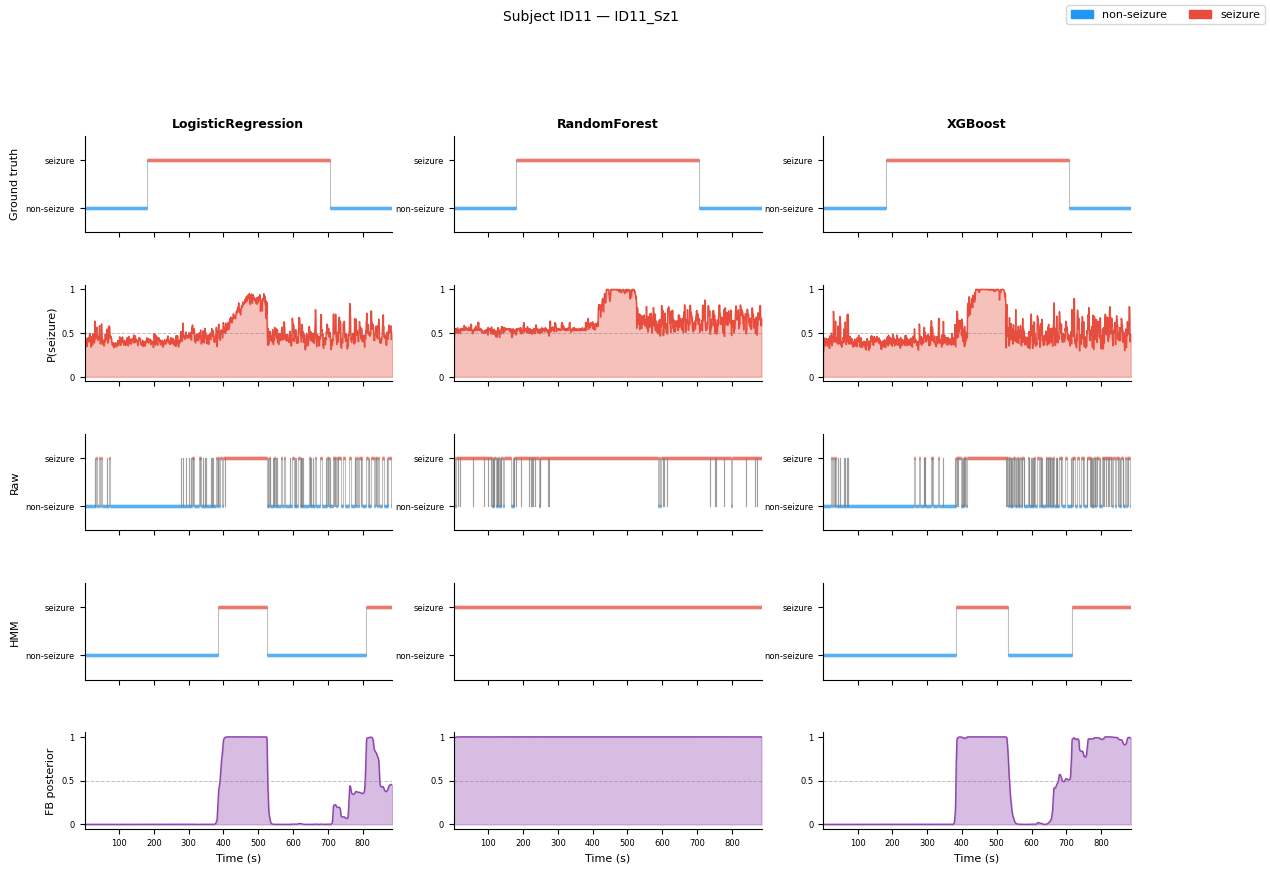

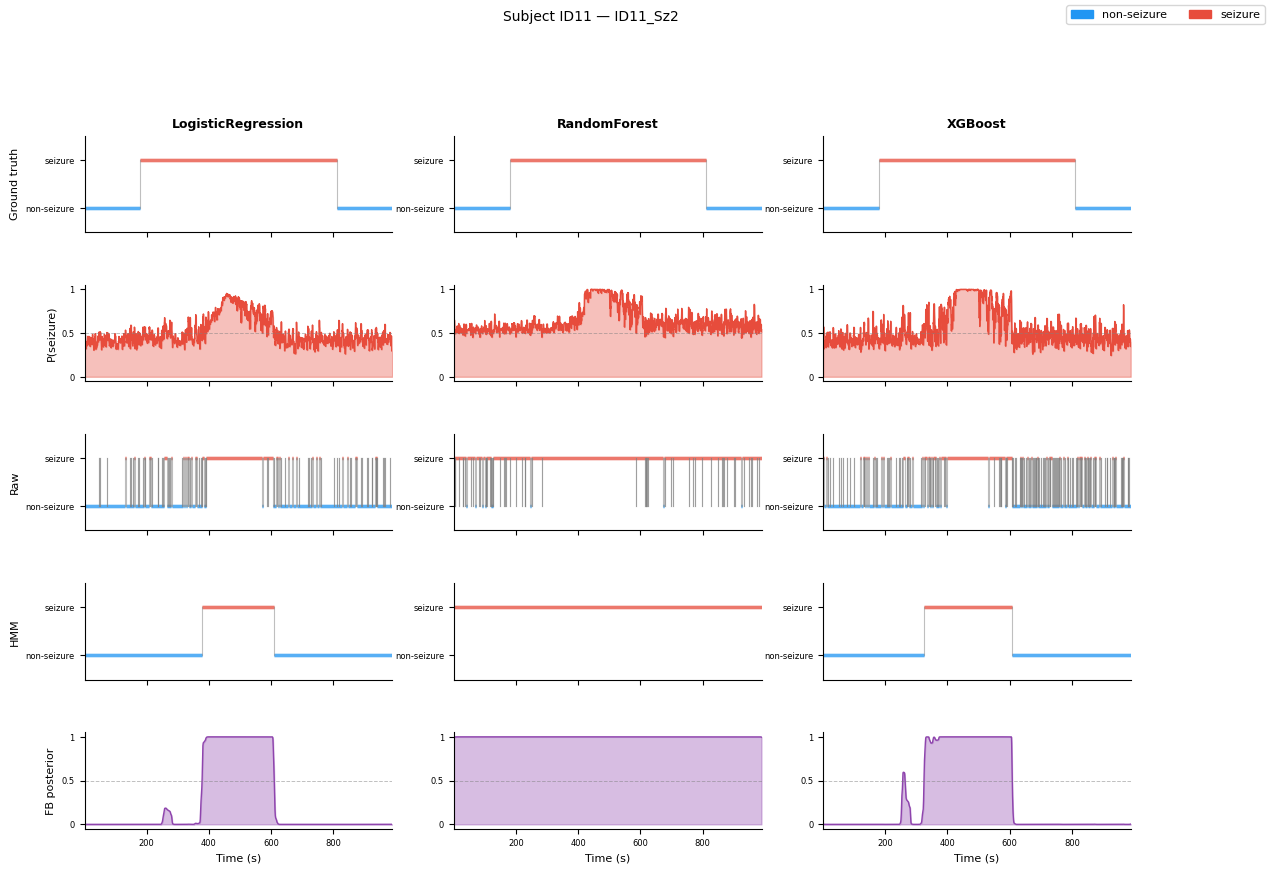

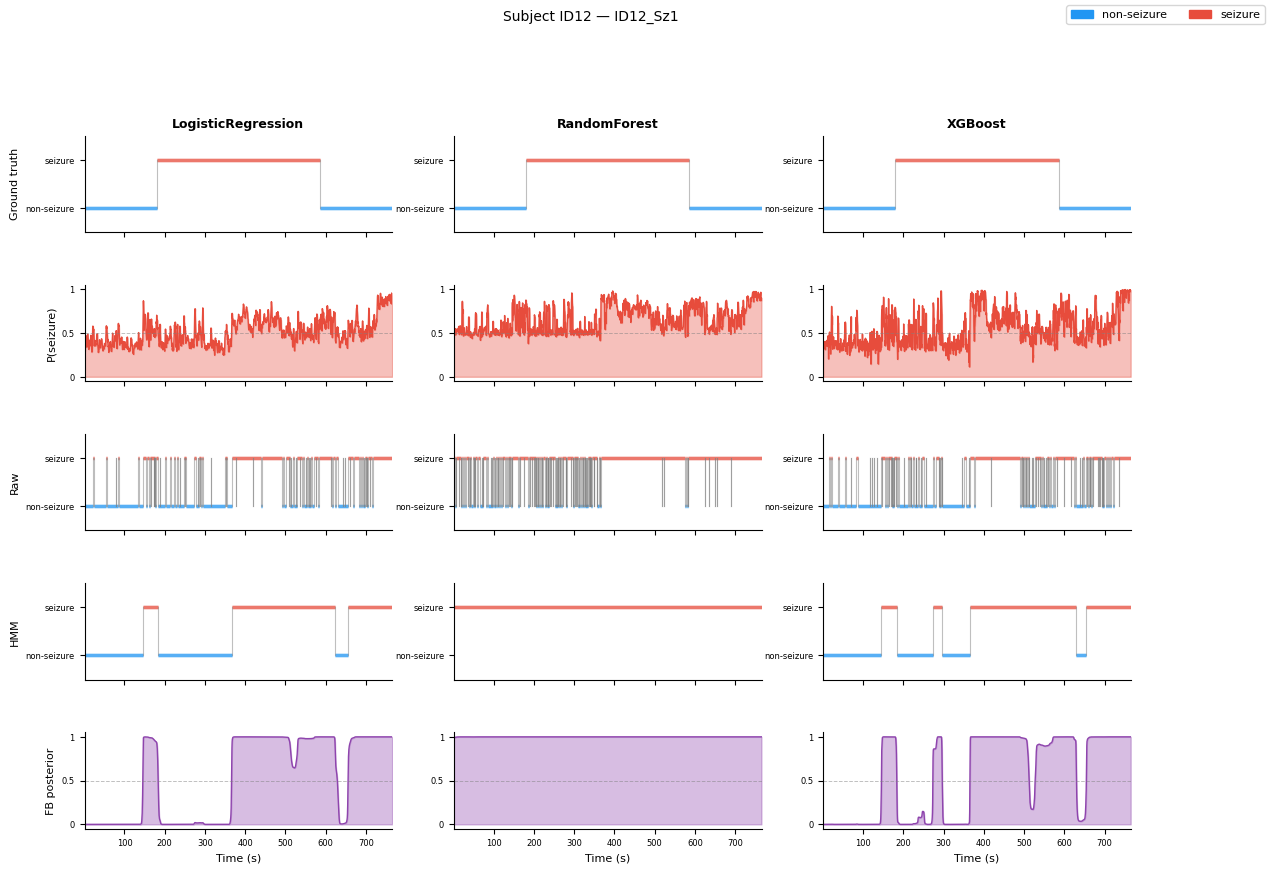

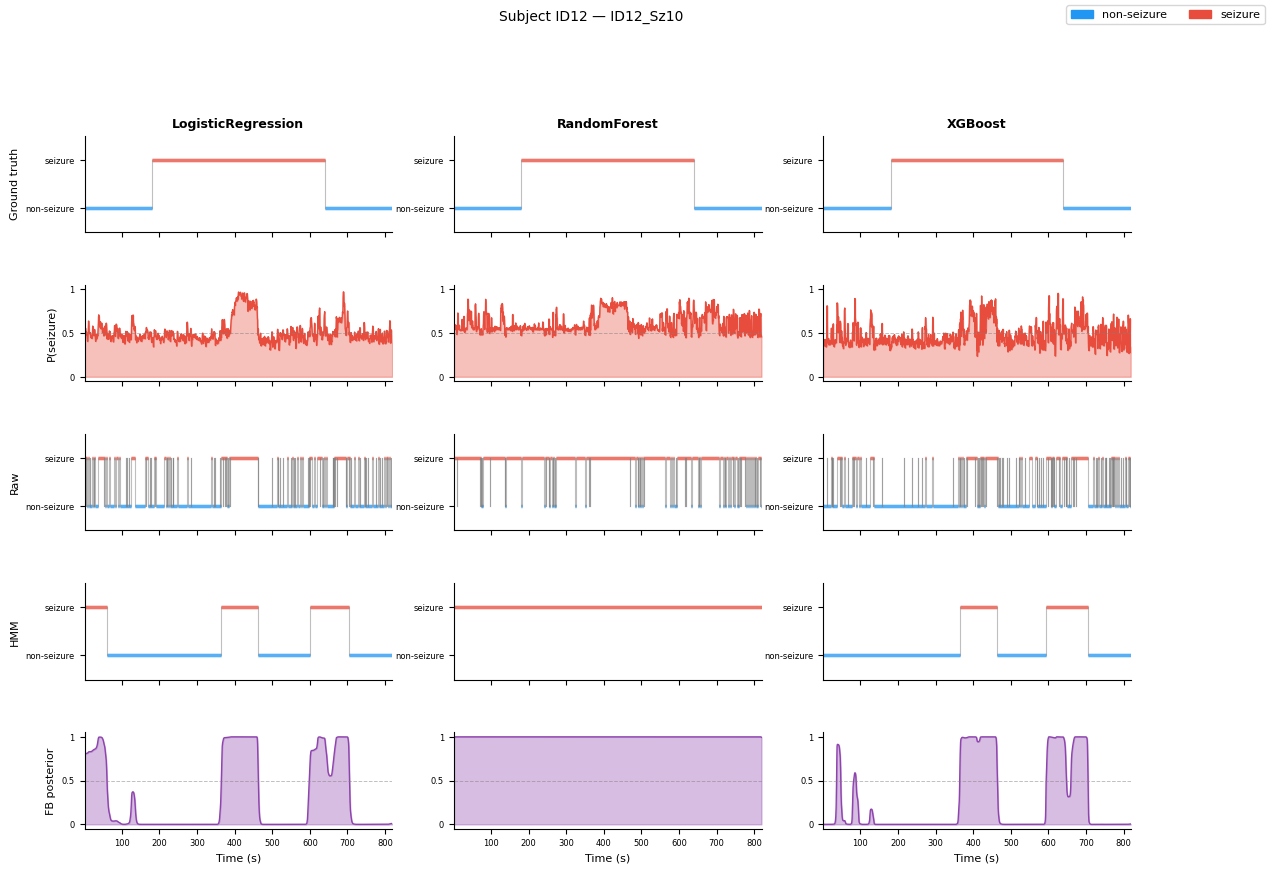

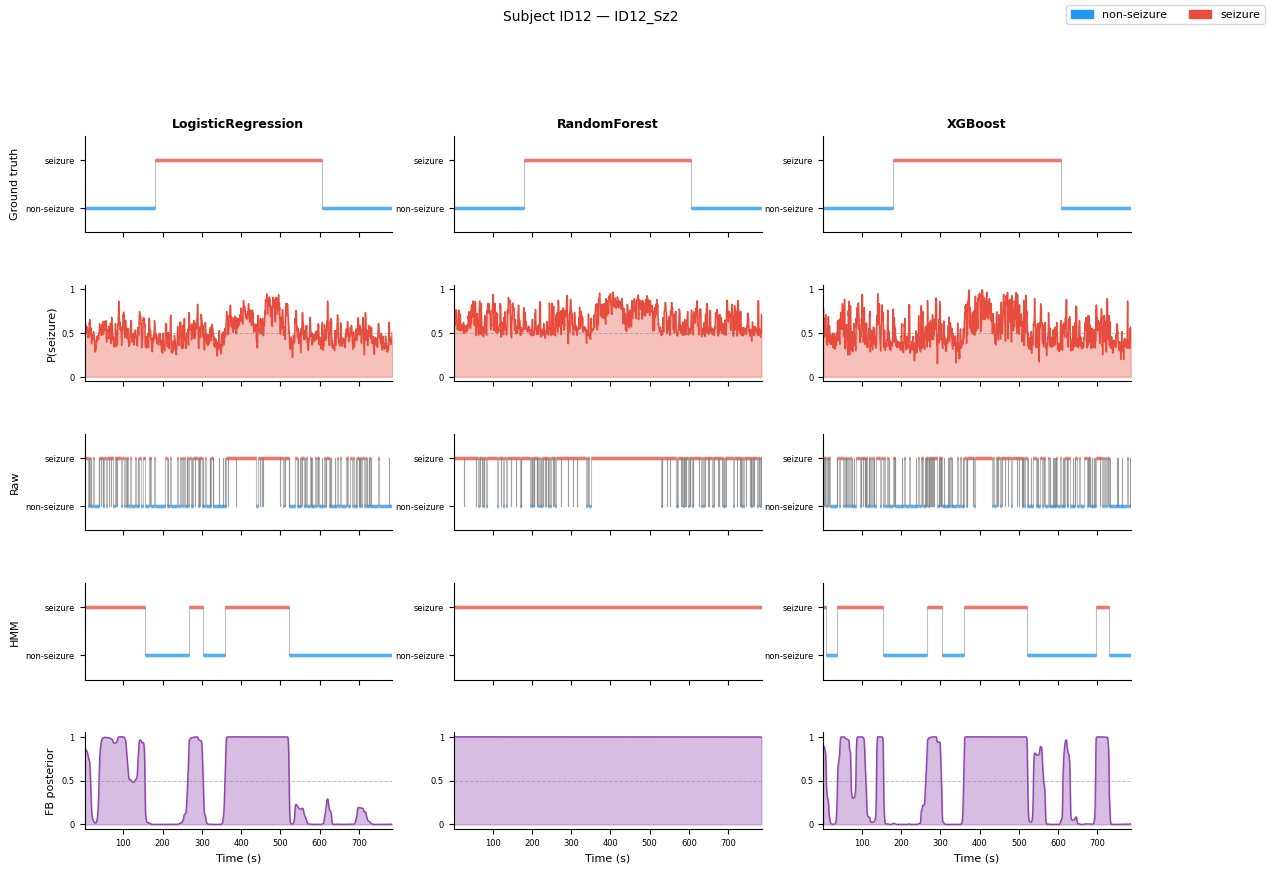

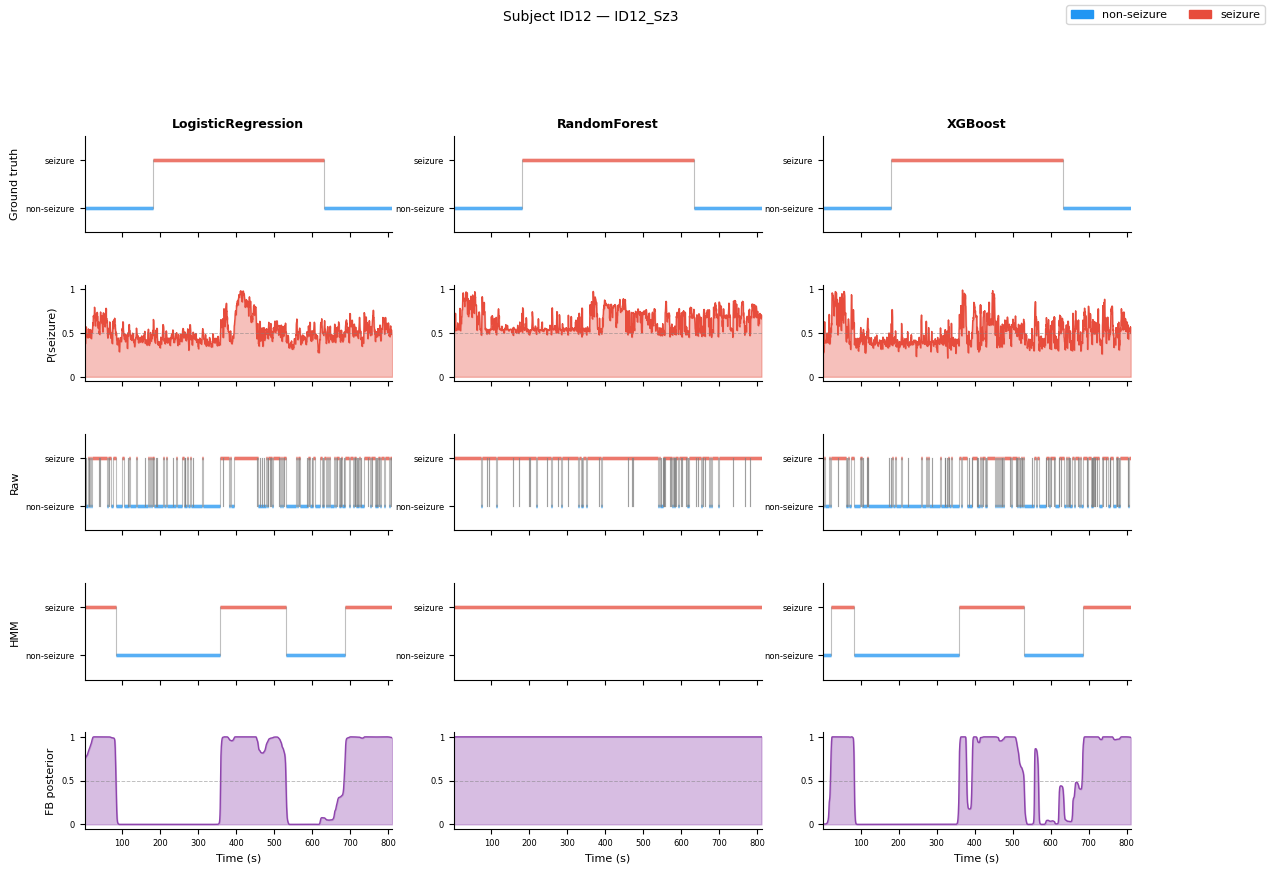

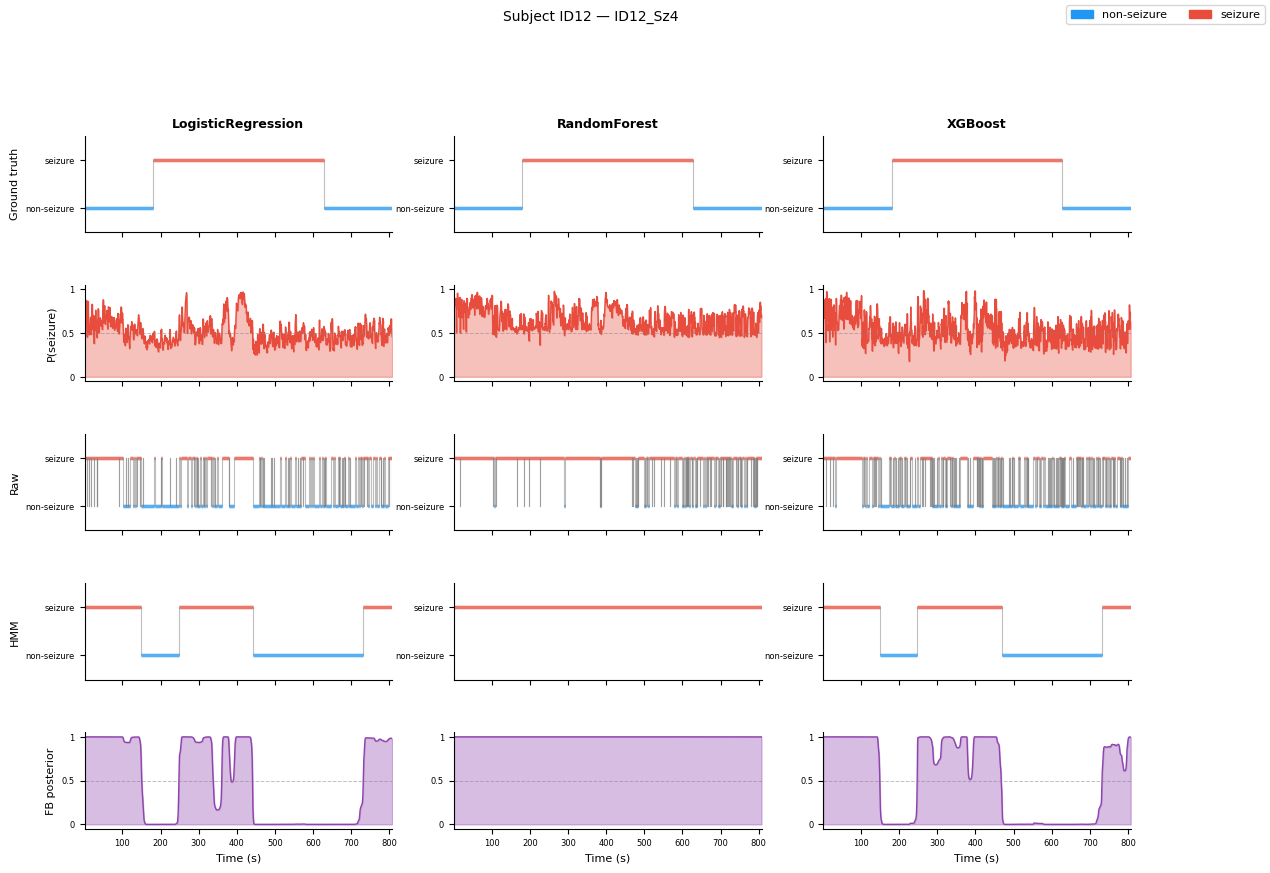

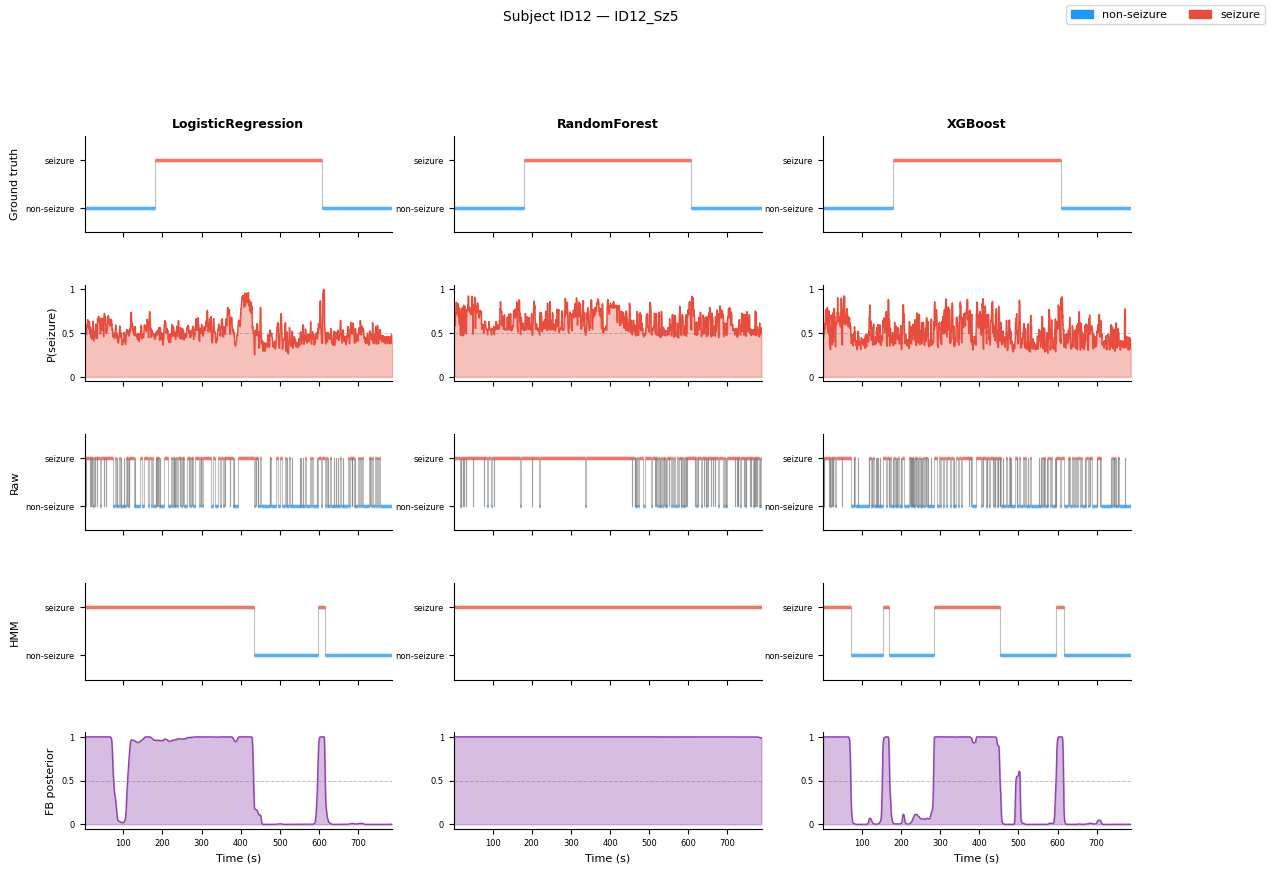

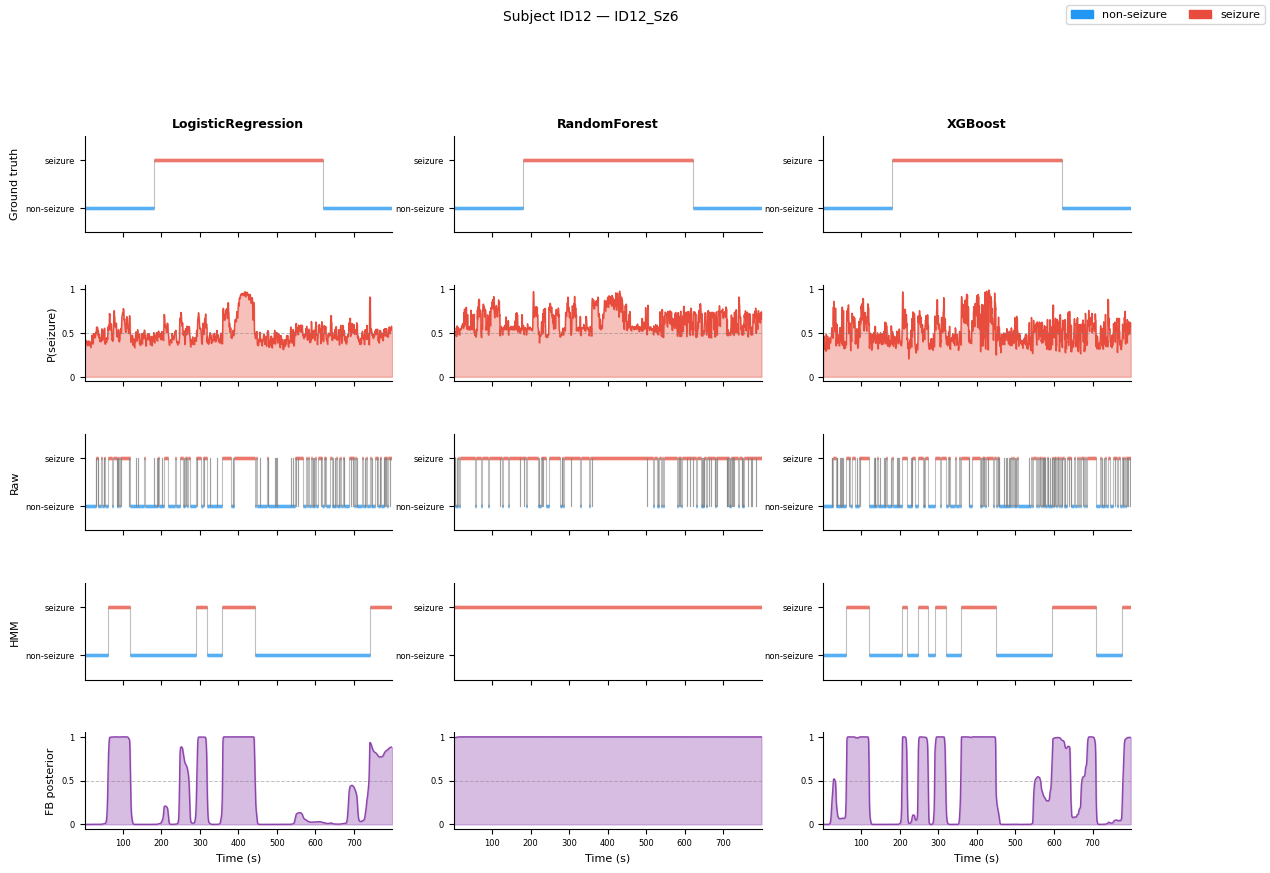

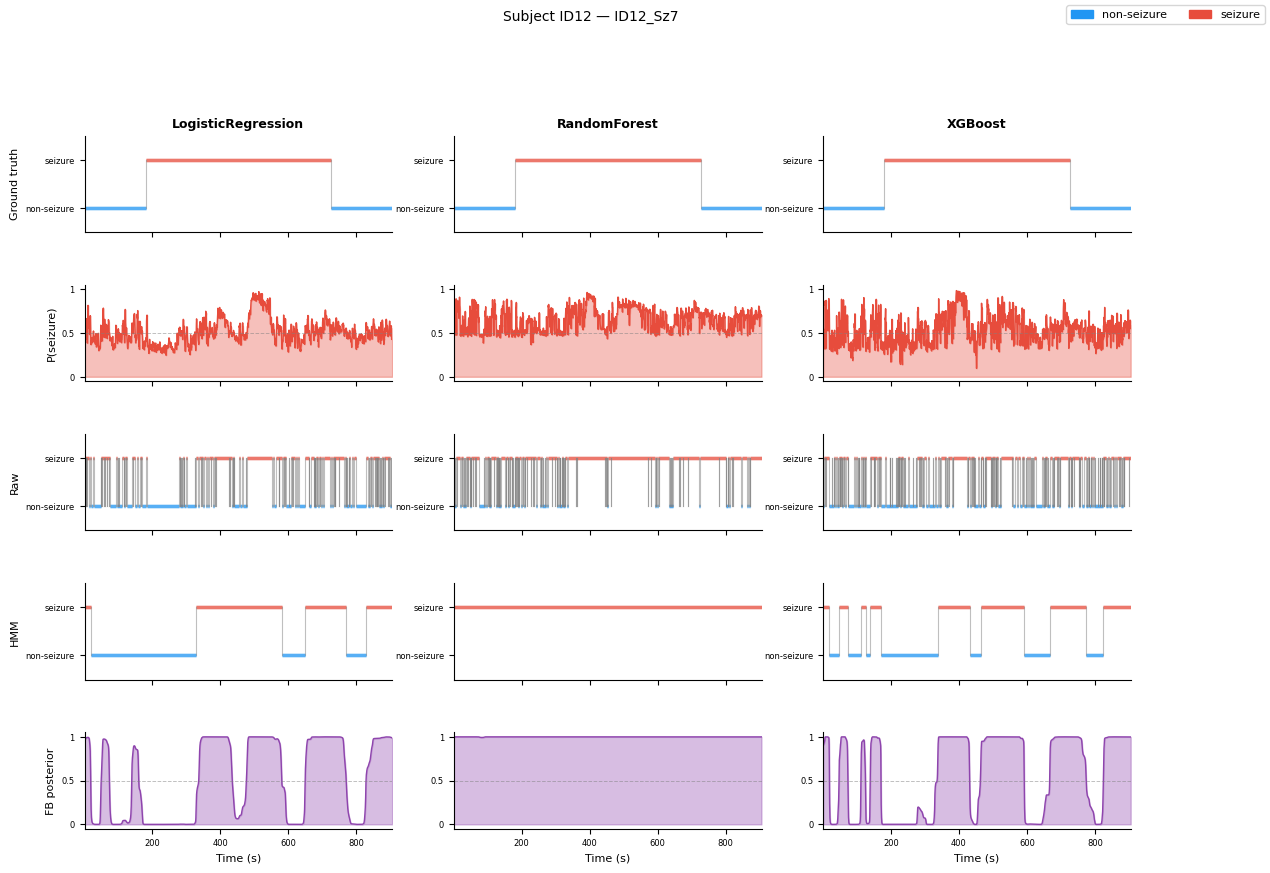

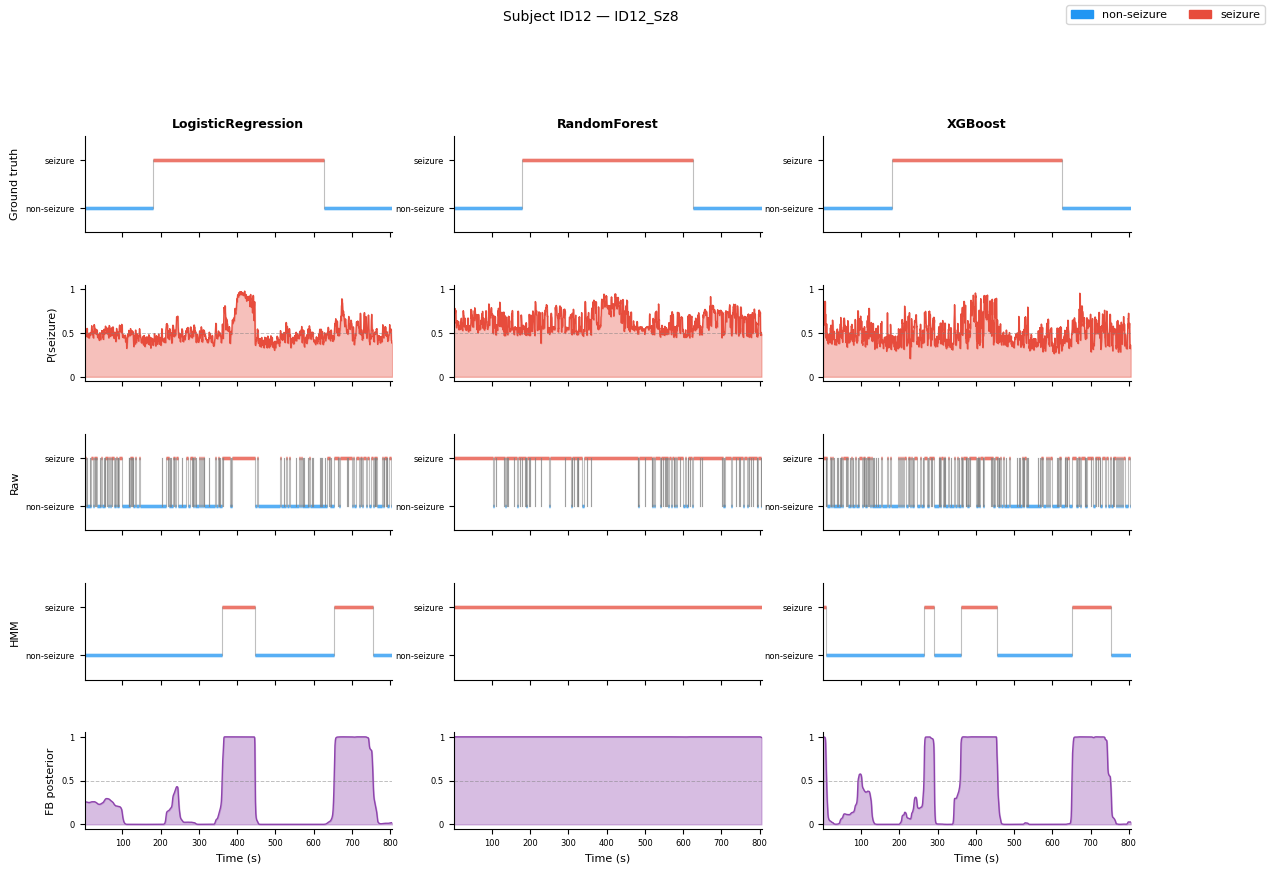

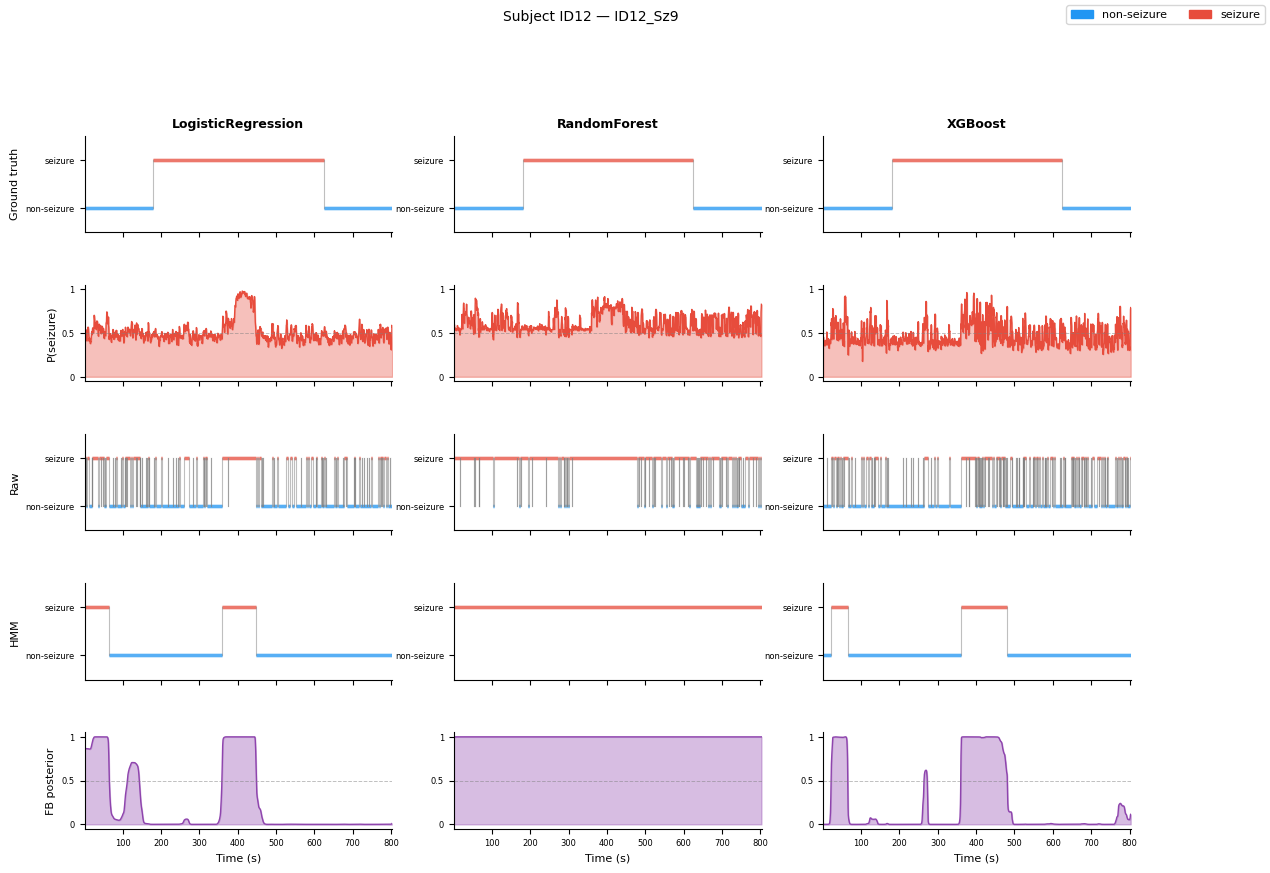

In [59]:
from matplotlib.collections import LineCollection

CLASS_COLORS_2 = {0: "#2196F3", 1: "#e74c3c"}
CLASS_NAMES_2 = {0: "non-seizure", 1: "seizure"}
FB_COLOR = "#8e44ad"  # purple for forward-backward posterior

CLF_LIST = list(CLASSIFIERS)
ROW_LABELS = ["Ground truth", "P(seizure)", "Raw", "HMM", "FB posterior"]


def _draw_hard(ax, times, labels, color_map, class_names):
    labels_int = np.asarray(labels, dtype=int)
    if len(times) > 1:
        dt = np.median(np.diff(times))
        t_left = np.concatenate([[times[0] - dt / 2], (times[:-1] + times[1:]) / 2])
        t_right = np.concatenate([(times[:-1] + times[1:]) / 2, [times[-1] + dt / 2]])
    else:
        dt = 5.0
        t_left = np.array([times[0] - dt / 2])
        t_right = np.array([times[0] + dt / 2])

    segments = [
        [(t_left[i], labels_int[i]), (t_right[i], labels_int[i])] for i in range(len(times))
    ]
    ax.add_collection(
        LineCollection(
            segments, colors=[color_map[lbl] for lbl in labels_int], linewidths=2.5, capstyle="butt"
        )
    )
    for i in range(len(times) - 1):
        if labels_int[i] != labels_int[i + 1]:
            ax.plot(
                [t_right[i], t_right[i]],
                [labels_int[i], labels_int[i + 1]],
                color="gray",
                linewidth=0.8,
                alpha=0.5,
            )

    n_cls = len(class_names)
    ax.set_xlim(times[0] - dt / 2, times[-1] + dt / 2)
    ax.set_ylim(-0.5, n_cls - 0.5)
    ax.set_yticks(list(class_names.keys()))
    ax.set_yticklabels(list(class_names.values()), fontsize=6)
    ax.tick_params(left=True, labelsize=6)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)


def _draw_prob(ax, times, p, color):
    ax.fill_between(times, 0, p, alpha=0.35, color=color)
    ax.plot(times, p, color=color, linewidth=1.0)
    ax.axhline(0.5, color="gray", linewidth=0.7, linestyle="--", alpha=0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "0.5", "1"], fontsize=6)
    ax.tick_params(left=True, labelsize=6)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)


legend_patches = [Patch(color=v, label=CLASS_NAMES_2[k]) for k, v in CLASS_COLORS_2.items()]

subjects_shown = 0
for fold in stored_folds:
    if N_SUBJECTS_PLOT and subjects_shown >= N_SUBJECTS_PLOT:
        break

    for stem in np.unique(fold["file_stems"]):
        mask = fold["file_stems"] == stem
        order = np.argsort(fold["window_mid_s"][mask])
        times = fold["window_mid_s"][mask][order]
        gt_2 = fold["y_true_2"][mask][order]
        stems_here = fold["file_stems"][mask][order]

        n_clfs = len(CLF_LIST)
        fig, axes = plt.subplots(
            5,
            n_clfs,
            figsize=(4.5 * n_clfs, 9),
            sharex=True,
            gridspec_kw={"hspace": 0.55, "wspace": 0.2},
        )

        for col_idx, clf_name in enumerate(CLF_LIST):
            probs = fold["probs_2"][clf_name][mask][order]

            # Row 0 — ground truth
            ax = axes[0, col_idx]
            _draw_hard(ax, times, gt_2, CLASS_COLORS_2, CLASS_NAMES_2)
            ax.set_title(clf_name, fontsize=9, fontweight="bold", pad=6)

            # Row 1 — raw P(seizure)
            ax = axes[1, col_idx]
            _draw_prob(ax, times, probs[:, 1], CLASS_COLORS_2[1])

            # Row 2 — raw argmax
            ax = axes[2, col_idx]
            _draw_hard(ax, times, probs.argmax(axis=1), CLASS_COLORS_2, CLASS_NAMES_2)

            # Row 3 — HMM (Viterbi)
            ax = axes[3, col_idx]
            hmm_pred = hmm_smooth(fold["y_train_2"], stems_here, probs, n_classes=2)
            _draw_hard(ax, times, hmm_pred, CLASS_COLORS_2, CLASS_NAMES_2)

            # Row 4 — forward-backward posterior
            ax = axes[4, col_idx]
            fb_post = hmm_forward_backward(fold["y_train_2"], stems_here, probs, n_classes=2)
            _draw_prob(ax, times, fb_post[:, 1], FB_COLOR)
            ax.set_xlabel("Time (s)", fontsize=8)

        for row_idx, row_label in enumerate(ROW_LABELS):
            axes[row_idx, 0].set_ylabel(row_label, fontsize=8, labelpad=4)

        subj = fold["test_subject"]
        fig.legend(handles=legend_patches, loc="upper right", fontsize=8, framealpha=0.8, ncol=2)
        fig.suptitle(f"Subject {subj} — {stem}", fontsize=10, y=1.02)
        plt.tight_layout()
        plt.show()

    subjects_shown += 1

## 10. Summary and next steps

The notebook has demonstrated a complete cross-patient seizure detection pipeline on the SWEZ short
dataset. Here is what was shown and what natural extensions look like.

### What this pipeline established

- 15 CobraBox features extracted from 98 recordings (190 k windows) generalise across 15 patients
  with Leave-One-Subject-Out validation.
- RFE with `k = 10` features was selected as the best trade-off; the consistently chosen features
  across folds indicate which signal aspects are most discriminative.
- HMM post-processing improves temporal consistency of predictions, especially at onset/offset
  boundaries where the raw classifier is most uncertain.
- The 4-class formulation does/does not outperform binary (inspect Section 8 results to confirm
  direction for this dataset).

### Potential next steps

| Direction | What to try |
|-----------|-------------|
| **Richer features** | Per-channel features (instead of mean-channel), or add phase-amplitude coupling, Hjorth parameters |
| **Better labelling** | If ground-truth onset/offset times become available, replace the fixed-margin rule with exact labels |
| **Deeper models** | LSTM or 1-D CNN on raw windows; compare to the classical feature pipeline |
| **Cross-dataset generalisation** | Re-run LOSO on a second dataset (e.g. CHBMIT) with the same pipeline to test portability |
| **Onset latency analysis** | Measure how many windows after true onset the model first correctly detects the seizure |
| **Confidence calibration** | Apply temperature scaling or Platt scaling to the probability outputs before HMM decoding |